# Paper plots — question-driven evidence

Locked config: `kl-diag-polar-lora` · PolarExpress PE=8 · Nesterov · β₁=0.9 · δ=1e-4 · k=1 · curvature_beta=0.99 · precond_refresh_every=10 · **precond_method=gram_ns**. AdamW, iMuon, Muon, and LoRA-RITE baselines are shown wherever reviewed evidence exists; σ=0.0017 noise floor.

In-flight runs render partially (`allow_partial=True`).

In [100]:
%load_ext autoreload
%autoreload 2

# Keep one module generation for the lifetime of the notebook kernel. Restart
# the kernel after editing plotting code so cached records and their classes
# cannot come from different imports.
import lora_playground.plotting.paper_plots_lib as P
from lora_playground.plotting.style import apply_notebook_style

apply_notebook_style()

# Every figure in one render sees the same log-tree state. Rerunning this setup
# cell refreshes the snapshot deliberately after new sweep results arrive.
P.begin_notebook_snapshot(refresh=True)

# Temporary compatibility imports for the remaining custom analysis cells.
# New and standard figure cells must call P.<entrypoint> directly.
from lora_playground.plotting.paper_plots_lib import (
    ROOT, SIGMA, ADAMW, PROTO, cell_runs,
    om as _om, pred_matches as _pred_matches, variant_key_fn as _variant_key_fn,
)
from lora_playground.plotting import compare_variants_figure


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1 — Does PoLoRA improve optimization across workloads and ranks?

### Code and out-of-distribution workload breadth

#### Figure 1. OLMo-2-1B · OPC · r=256

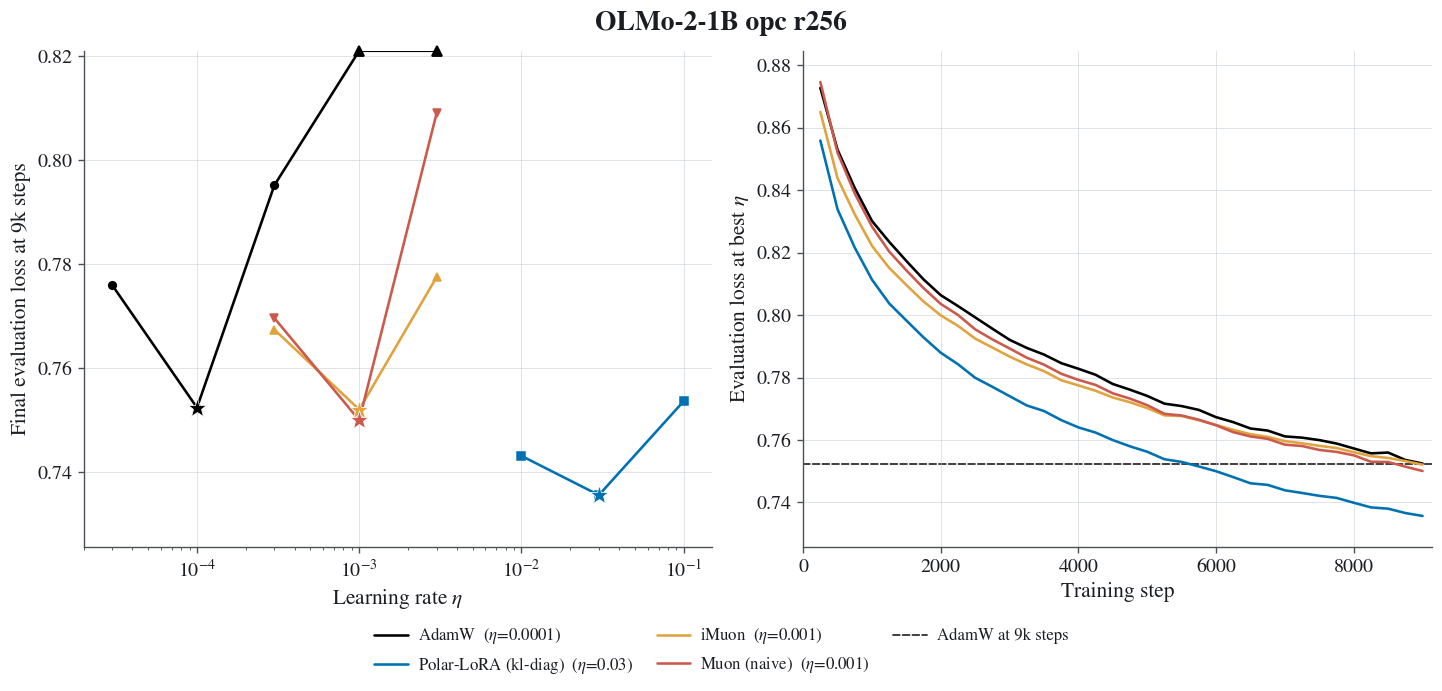

speedup vs AdamW (target 0.7524, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.7356     1.61x    1.26x  3
  Muon (naive)              0.001   0.7500     1.05x    1.02x  3
  iMuon                     0.001   0.7521     1.01x    1.00x  3
  AdamW                    0.0001   0.7524     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.752439,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.735641,-0.016797,-9.880739,1
2,iMuon,0.0010,0.752073,-0.000365,-0.214891,1
3,Muon (naive),0.0010,0.750033,-0.002406,-1.415284,1


In [101]:
P.panel_n(0)   # OLMo-2-1B opc r256


#### Figure 2. Qwen2.5-1.5B · OPC · r=256

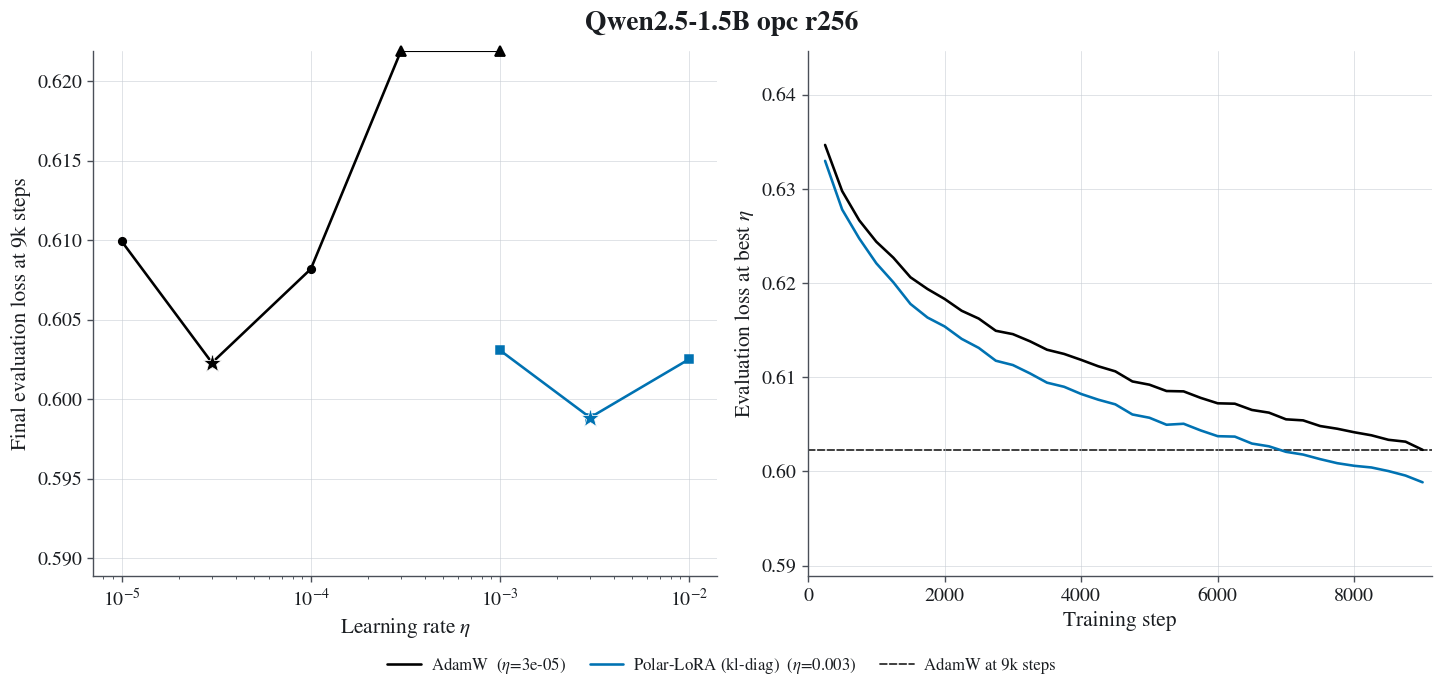

speedup vs AdamW (target 0.6023, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.5988     1.30x    1.08x  3
  AdamW                     3e-05   0.6023     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.602292,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.598845,-0.003447,-2.027497,1


In [102]:
P.panel_n(1)   # Qwen2.5-1.5B opc r256


#### Figure 3. Llama-3.2-1B · OPC · r=256

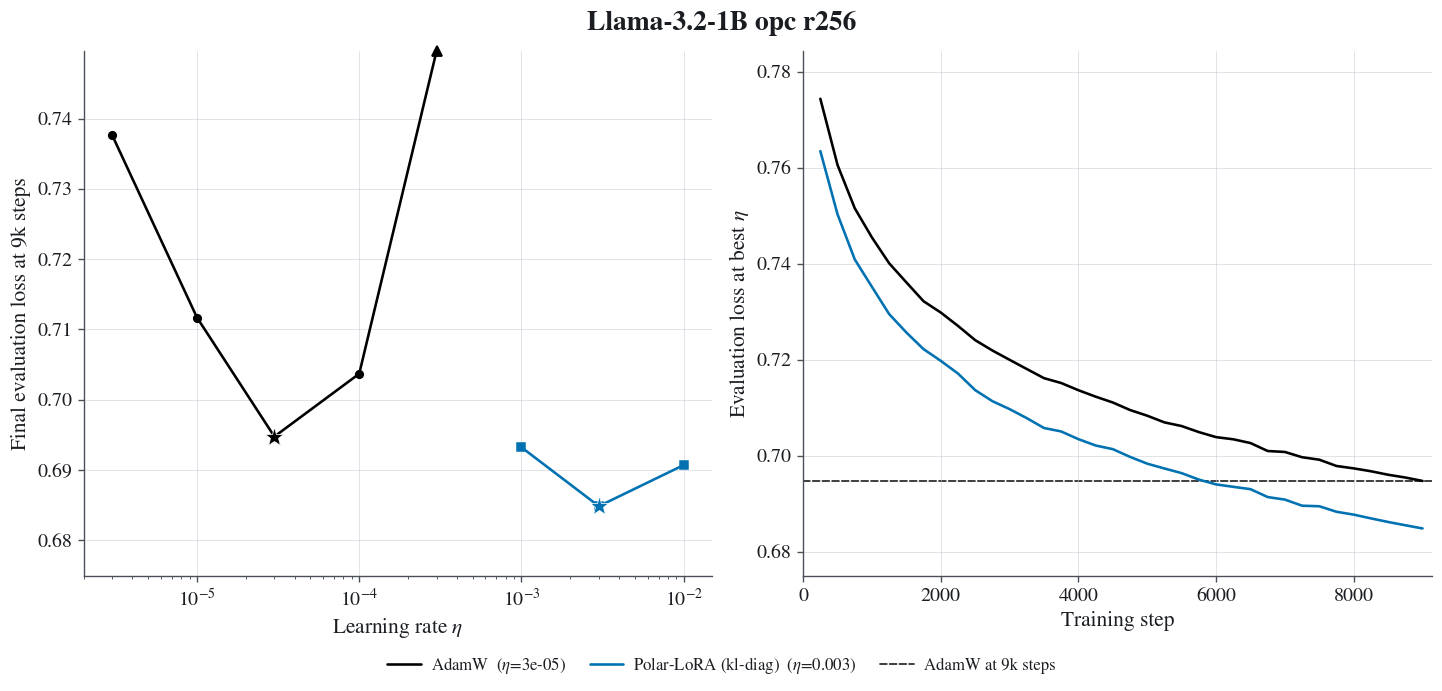

speedup vs AdamW (target 0.6948, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.6848     1.55x    1.24x  3
  AdamW                     3e-05   0.6948     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.694754,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.684849,-0.009905,-5.826258,1


In [103]:
P.panel_n(2)   # Llama-3.2-1B opc r256


#### Figure 4. Llama-3-8B · OPC · r=256

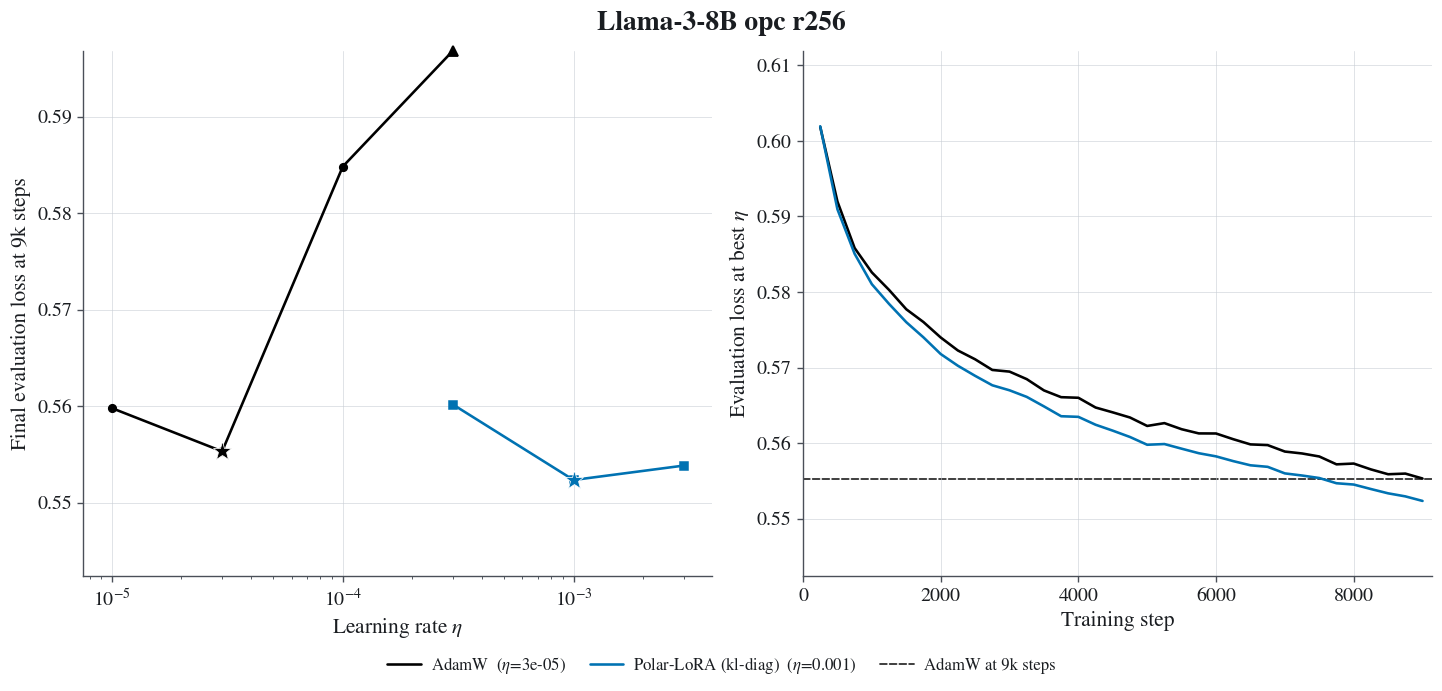

speedup vs AdamW (target 0.5553, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.001   0.5523     1.20x    1.09x  3
  AdamW                     3e-05   0.5553     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.555303,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00100,0.552333,-0.00297,-1.747025,1


In [104]:
P.panel_n(3)   # Llama-3-8B opc r256


#### Figure 5. Qwen2.5-1.5B · Bengali · r=256 (OOD pair)

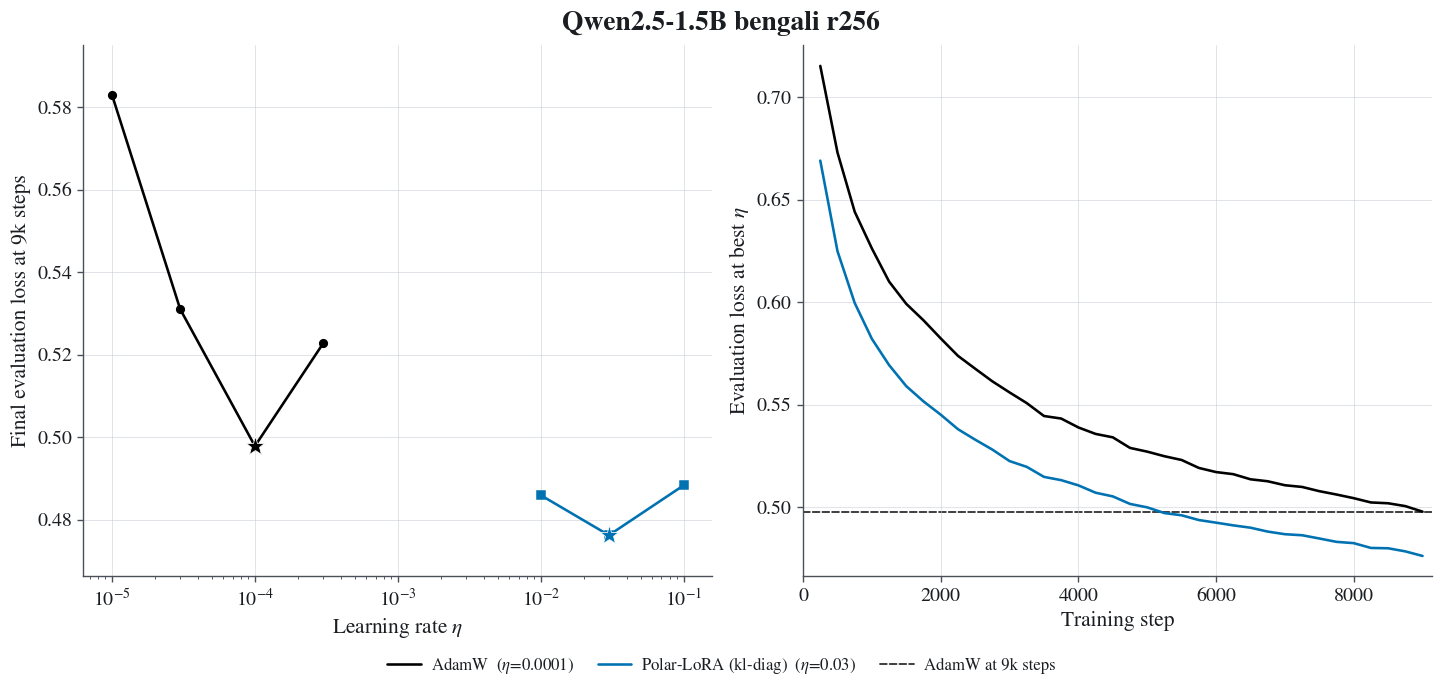

speedup vs AdamW (target 0.4979, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.4763     1.73x    1.39x  3
  AdamW                    0.0001   0.4979     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.497858,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.476251,-0.021607,-12.710198,1


In [105]:
P.panel_n(4)   # Qwen2.5-1.5B bengali r256


### Math workload breadth

#### Figure 6. OLMo-2-1B · OpenMath · r=256

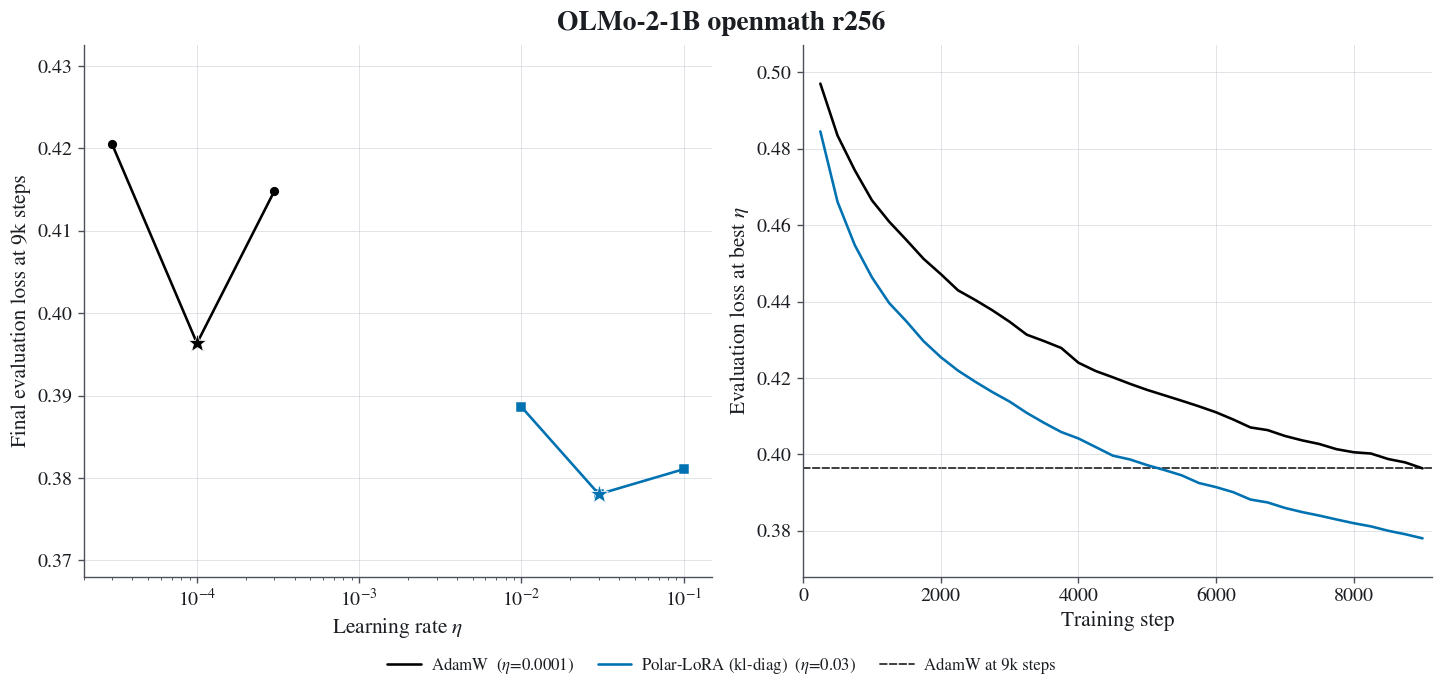

speedup vs AdamW (target 0.3964, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.3780     1.74x    1.50x  3
  AdamW                    0.0001   0.3964     1.00x    1.00x  3


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.396363,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.378044,-0.01832,-10.77627,1


In [106]:
P.panel_n(5)   # OLMo-2-1B openmath r256


#### Figure 7. Qwen2.5-1.5B · OpenMath · r=256

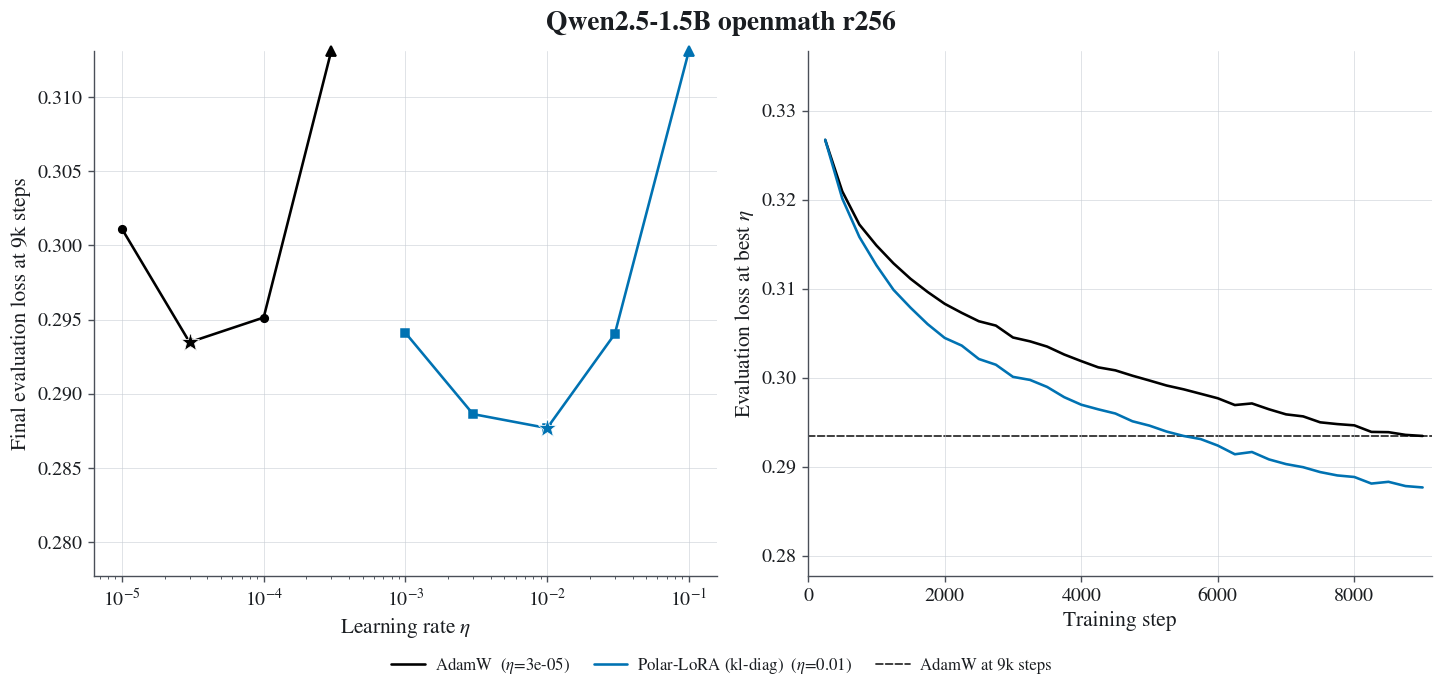

speedup vs AdamW (target 0.2935, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.2877     1.64x    1.33x  5
  AdamW                     3e-05   0.2935     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.293472,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.01000,0.287687,-0.005785,-3.402839,1


In [107]:
P.panel_n(6)   # Qwen2.5-1.5B openmath r256


#### Figure 8. Llama-3-8B · OpenMath · r=256

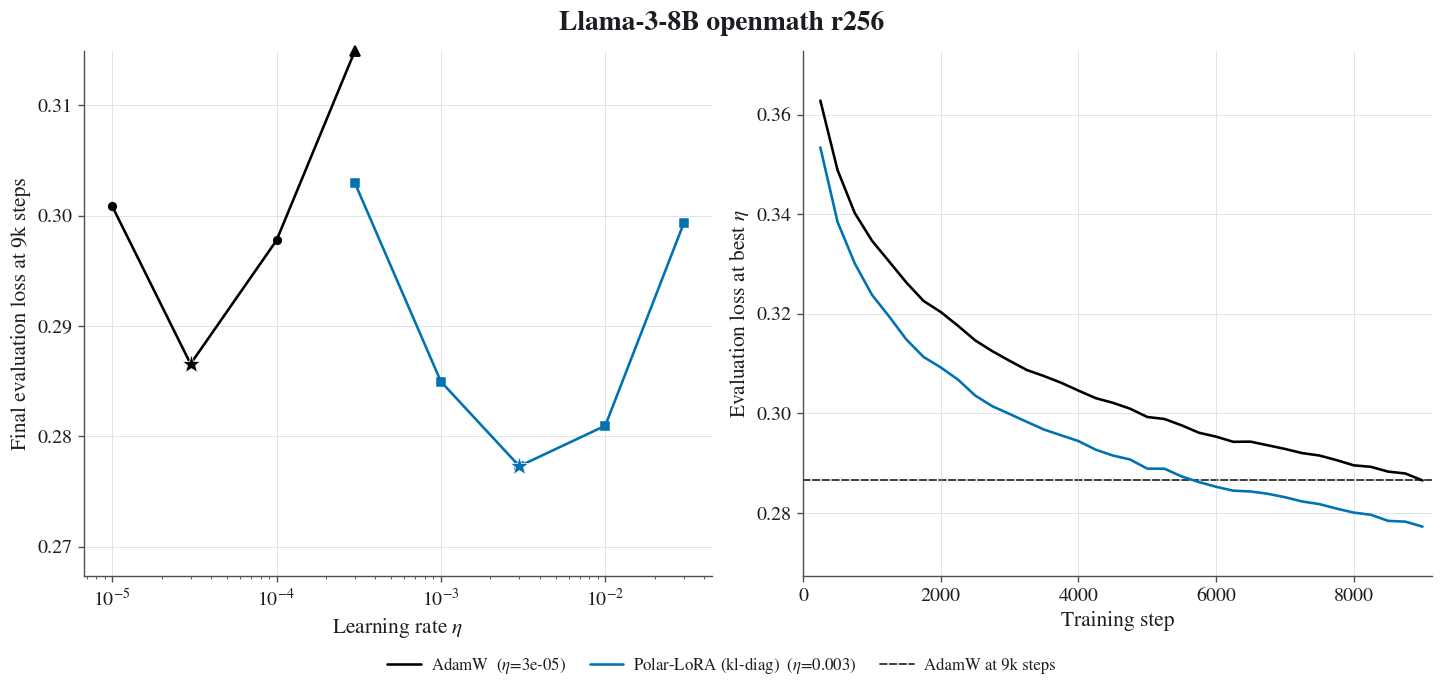

speedup vs AdamW (target 0.2866, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.2773     1.59x    1.25x  5
  AdamW                     3e-05   0.2866     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.286564,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.277293,-0.00927,-5.452999,1


In [108]:
P.panel_n(7)   # Llama-3-8B openmath r256


### Rank transfer on Llama-3.2-1B · OpenMath

#### Figure 9. r=16

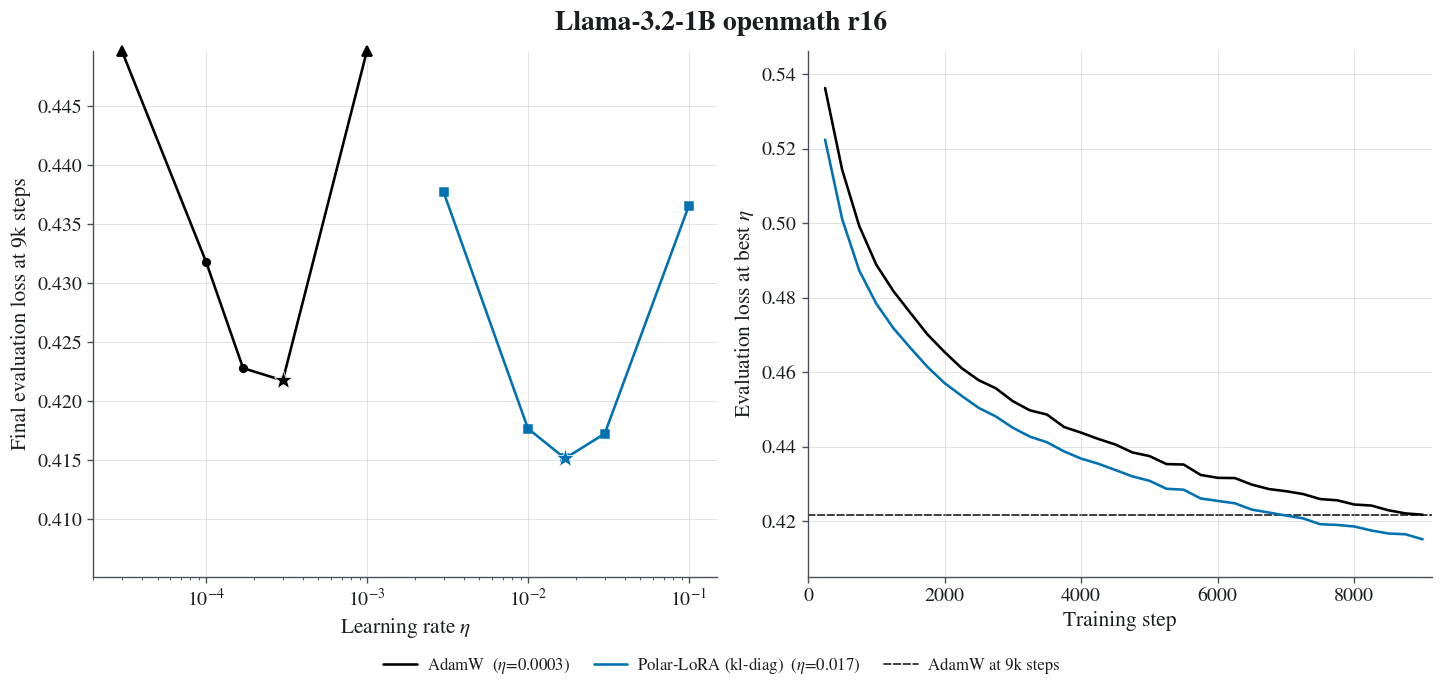

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.017   0.4152     1.30x    1.23x  5
  AdamW                    0.0003   0.4218     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0170,0.415162,-0.006601,-3.883152,1


In [109]:
P.panel_n(8)   # Llama-3.2-1B openmath r16


#### Figure 10. r=32

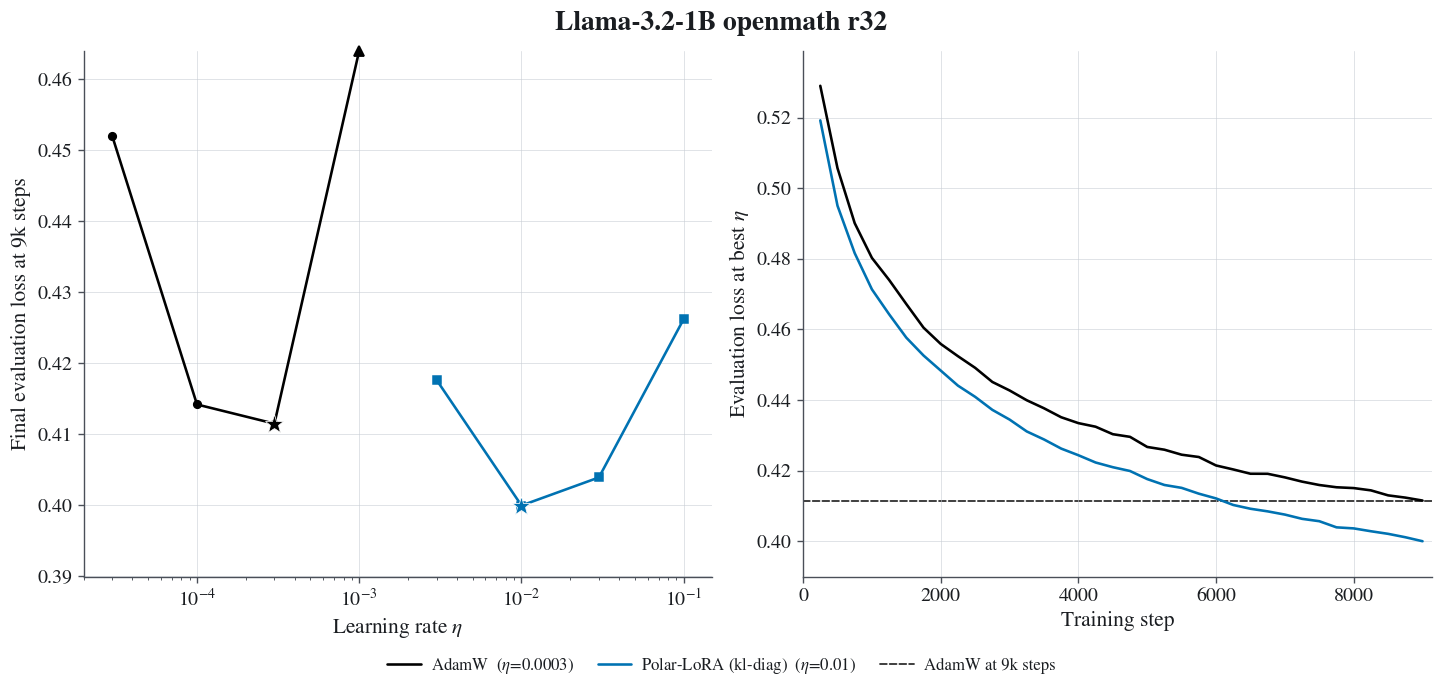

speedup vs AdamW (target 0.4115, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.4000     1.48x    1.23x  4
  AdamW                    0.0003   0.4115     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.411517,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.399991,-0.011526,-6.779981,1


In [110]:
P.panel_n(9)   # Llama-3.2-1B openmath r32


#### Figure 11. r=64

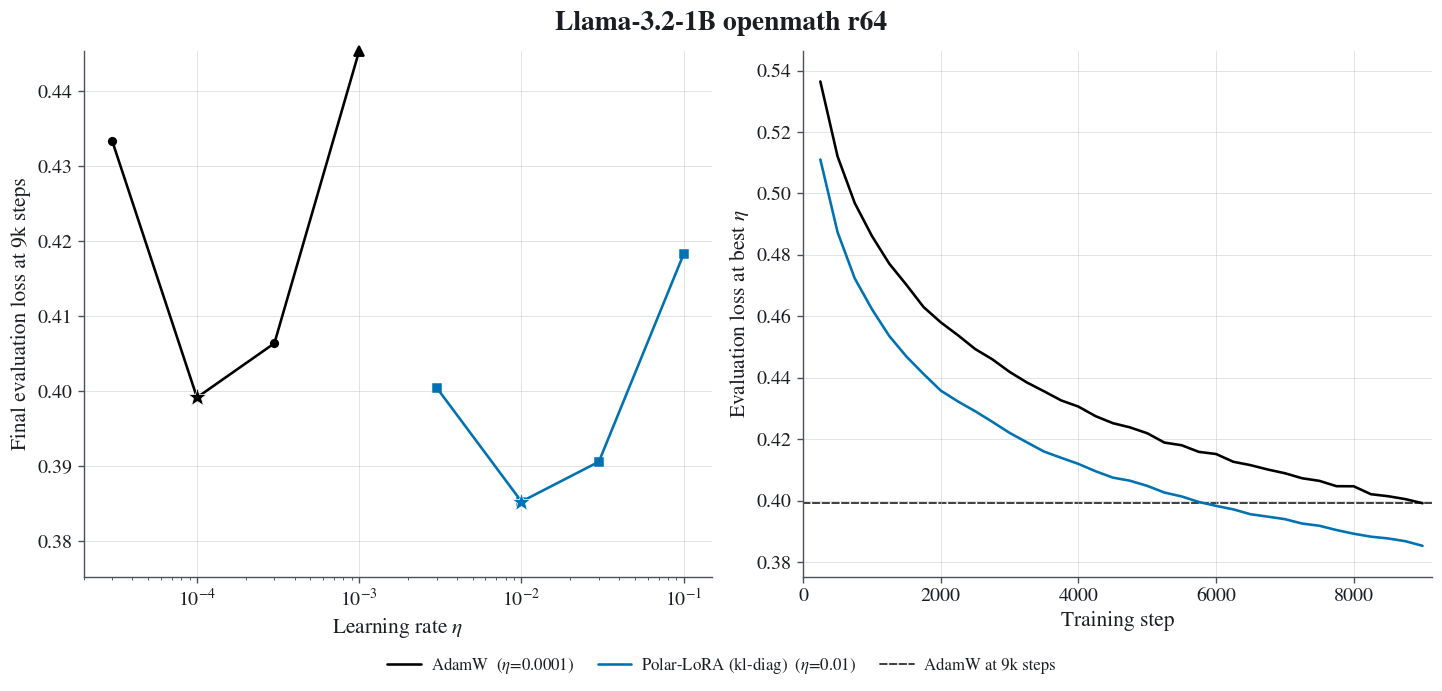

speedup vs AdamW (target 0.3991, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.3853     1.54x    1.25x  4
  AdamW                    0.0001   0.3991     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.399128,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.385254,-0.013874,-8.160944,1


In [111]:
P.panel_n(10)   # Llama-3.2-1B openmath r64


#### Figure 12. r=128

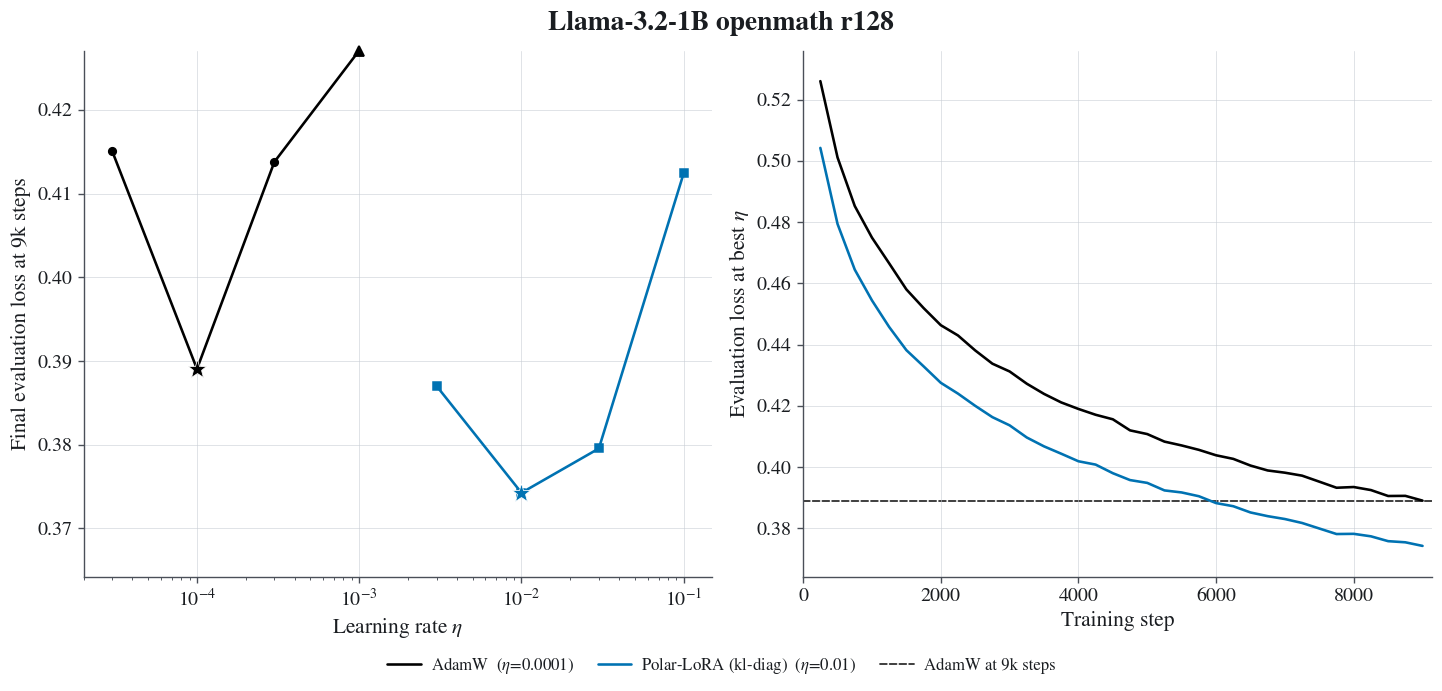

speedup vs AdamW (target 0.3890, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.3743     1.52x    1.28x  4
  AdamW                    0.0001   0.3890     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.389044,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.374259,-0.014785,-8.696915,1


In [112]:
P.panel_n(11)   # Llama-3.2-1B openmath r128


#### Figure 13. r=256

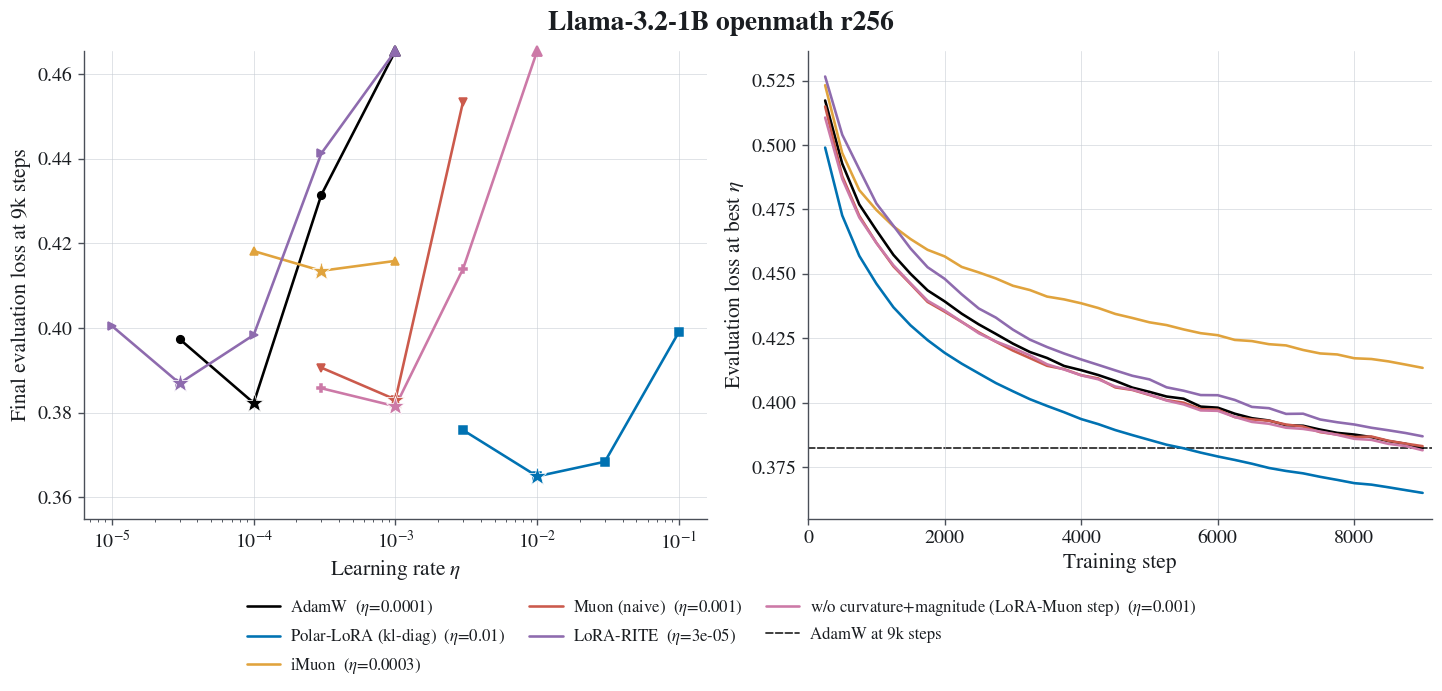

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                        best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)                           0.01   0.3650     1.64x    1.40x  4
  w/o curvature+magnitude (LoRA-Muon step)      0.001   0.3815     1.01x    1.00x  4
  AdamW                                        0.0001   0.3823     1.00x    1.00x  4
  iMuon                                        0.0003   0.4135         —    1.00x  3
  Muon (naive)                                  0.001   0.3831         —    1.00x  3
  LoRA-RITE                                     3e-05   0.3869         —    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00010,0.382301,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.01000,0.364971,-0.017329,-10.193808,4
2,iMuon,0.00030,0.413505,0.031204,18.355461,1
3,Muon (naive),0.00100,0.383107,0.000807,0.474588,1
4,LoRA-RITE,0.00003,0.386939,0.004638,2.728313,1
5,w/o curvature+magnitude (LoRA-Muon step),0.00100,0.381511,-0.000790,-0.464564,1


In [113]:
P.panel_n(12)   # Llama-3.2-1B openmath r256


The overlay below asks whether the preferred learning-rate basin transfers across the full rank ladder.

### Figure 14. Rank-ladder final loss versus learning rate

── fig3 lr transfer (openmath rank ladder) ──
  r16 PoLoRA       best_lr 0.017  final 0.4152
  r16 Adam         best_lr 0.0003  final 0.4218
  r32 PoLoRA       best_lr 0.01  final 0.4000
  r32 Adam         best_lr 0.0003  final 0.4115
  r64 PoLoRA       best_lr 0.01  final 0.3853
  r64 Adam         best_lr 0.0001  final 0.3991
  r128 PoLoRA       best_lr 0.01  final 0.3743
  r128 Adam         best_lr 0.0001  final 0.3890
  r256 PoLoRA       best_lr 0.01  final 0.3650
  r256 Adam         best_lr 0.0001  final 0.3823


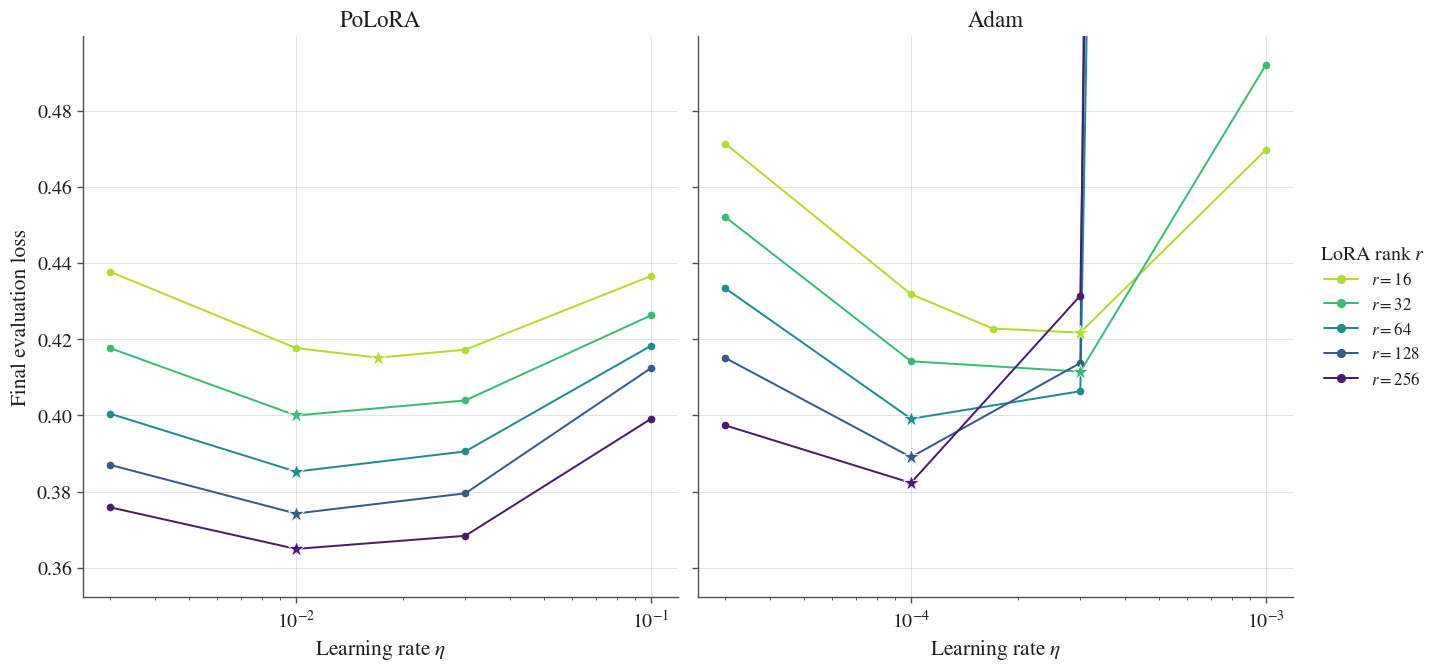

In [114]:
# Final eval loss vs learning rate across the Llama openmath rank ladder.
# The shared records-native function owns loading, aggregation, and rendering.
P.rank_lr_panel();


## Question 2 — Which update ingredients drive the gain?

### Figure 15. Component ablation

no data yet (omitted): Without magnitude rescale


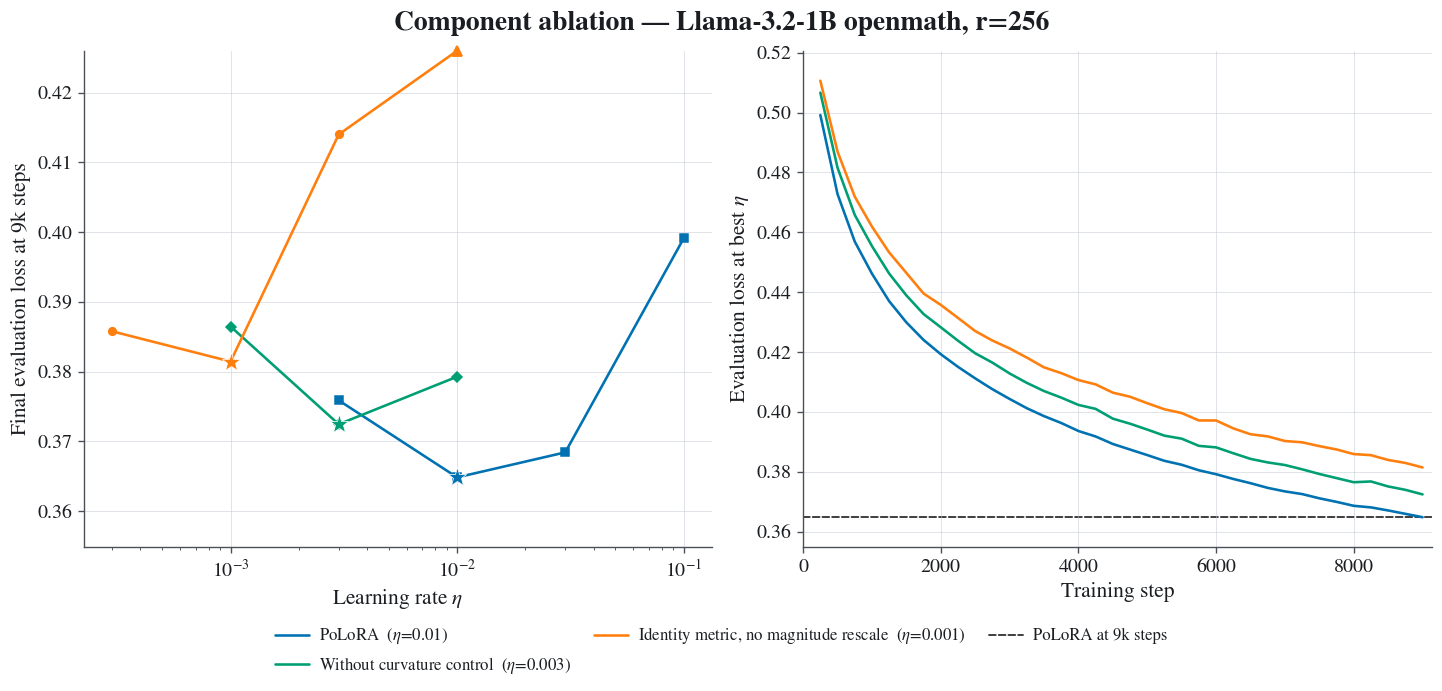

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,PoLoRA,0.010,0.364831,NaN,NaN,5
1,Without curvature control,0.003,0.372446,0.007615,4.479246,1
2,"Identity metric, no magnitude rescale",0.001,0.381439,0.016608,9.769597,2


In [115]:
P.ablation_panel(256)


### Figure 16. Orthogonalization versus metric power

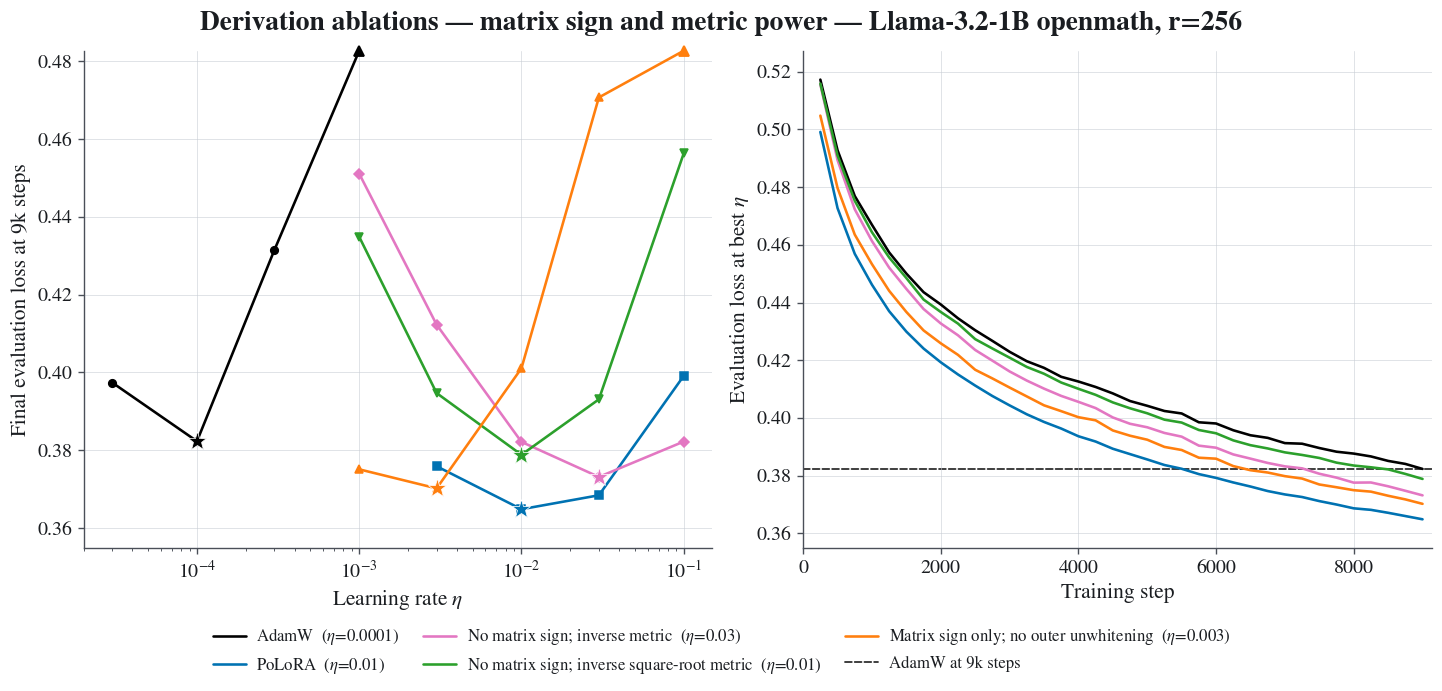

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  PoLoRA                                           0.01   0.3648     1.63x    1.40x  4
  Matrix sign only; no outer unwhitening          0.003   0.3702     1.40x    1.18x  5
  No matrix sign; inverse metric                   0.03   0.3731     1.24x    1.07x  5
  No matrix sign; inverse square-root metric       0.01   0.3788     1.07x    1.02x  5
  AdamW                                          0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.382301,0.017470,10.276285,1
1,PoLoRA,0.0100,0.364831,NaN,NaN,5
2,No matrix sign; inverse metric,0.0300,0.373131,0.008300,4.882538,2
3,No matrix sign; inverse square-root metric,0.0100,0.378824,0.013993,8.231263,1
4,Matrix sign only; no outer unwhitening,0.0030,0.370188,0.005357,3.151343,1


In [116]:
P.derivation_ablation_panel(256)


### Figure 17. Full versus diagonal matrix sign

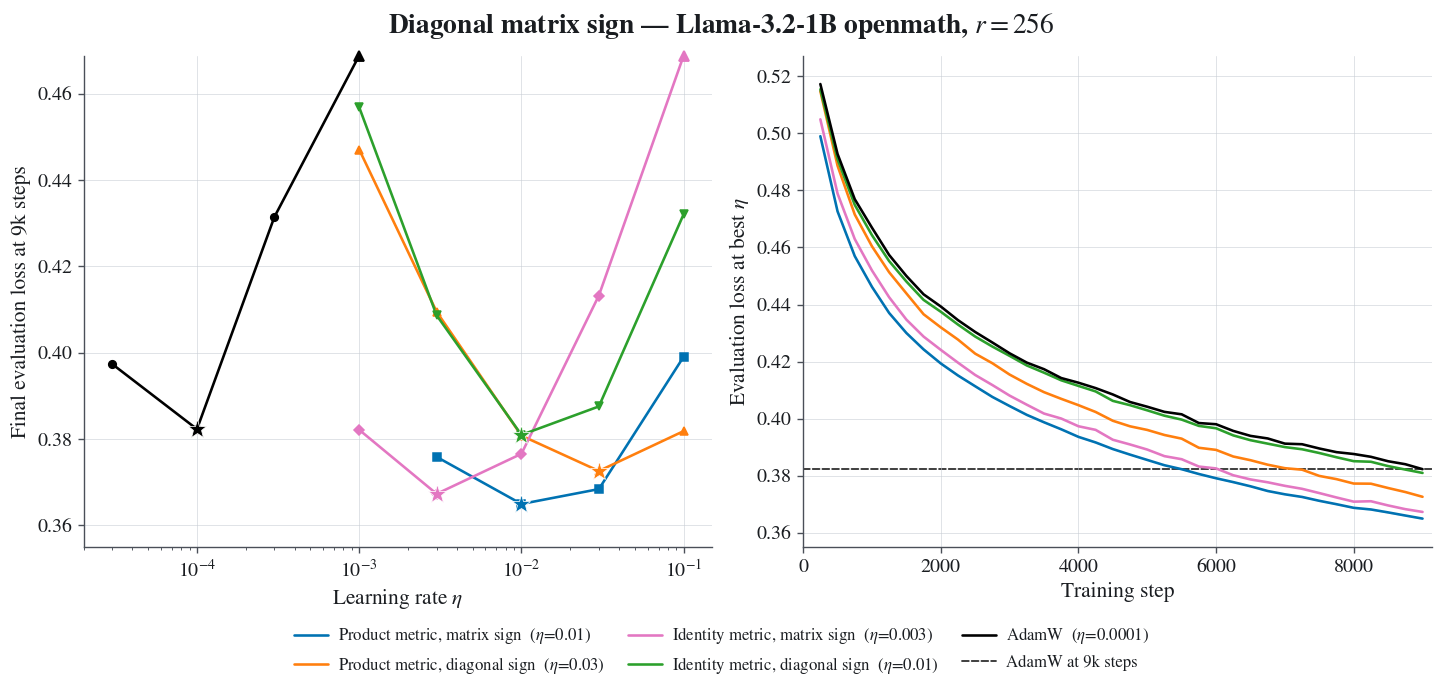

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                              best eta    final   speedup   lr-avg  n_lr
  Product metric, matrix sign          0.01   0.3650     1.64x    1.40x  4
  Identity metric, matrix sign        0.003   0.3673     1.49x    1.20x  5
  Product metric, diagonal sign        0.03   0.3726     1.26x    1.09x  5
  Identity metric, diagonal sign       0.01   0.3810     1.03x    1.01x  5
  AdamW                              0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,"Product metric, matrix sign",0.0100,0.364971,NaN,NaN,4
1,"Product metric, diagonal sign",0.0300,0.372614,0.007642,4.495528,1
2,"Identity metric, matrix sign",0.0030,0.367310,0.002339,1.375909,1
3,"Identity metric, diagonal sign",0.0100,0.380976,0.016005,9.414755,1
4,AdamW,0.0001,0.382301,0.017329,10.193808,1


In [117]:
P.msign_panel(256)


### Figure 18. Spectral-norm magnitude rule versus naive ρ=η

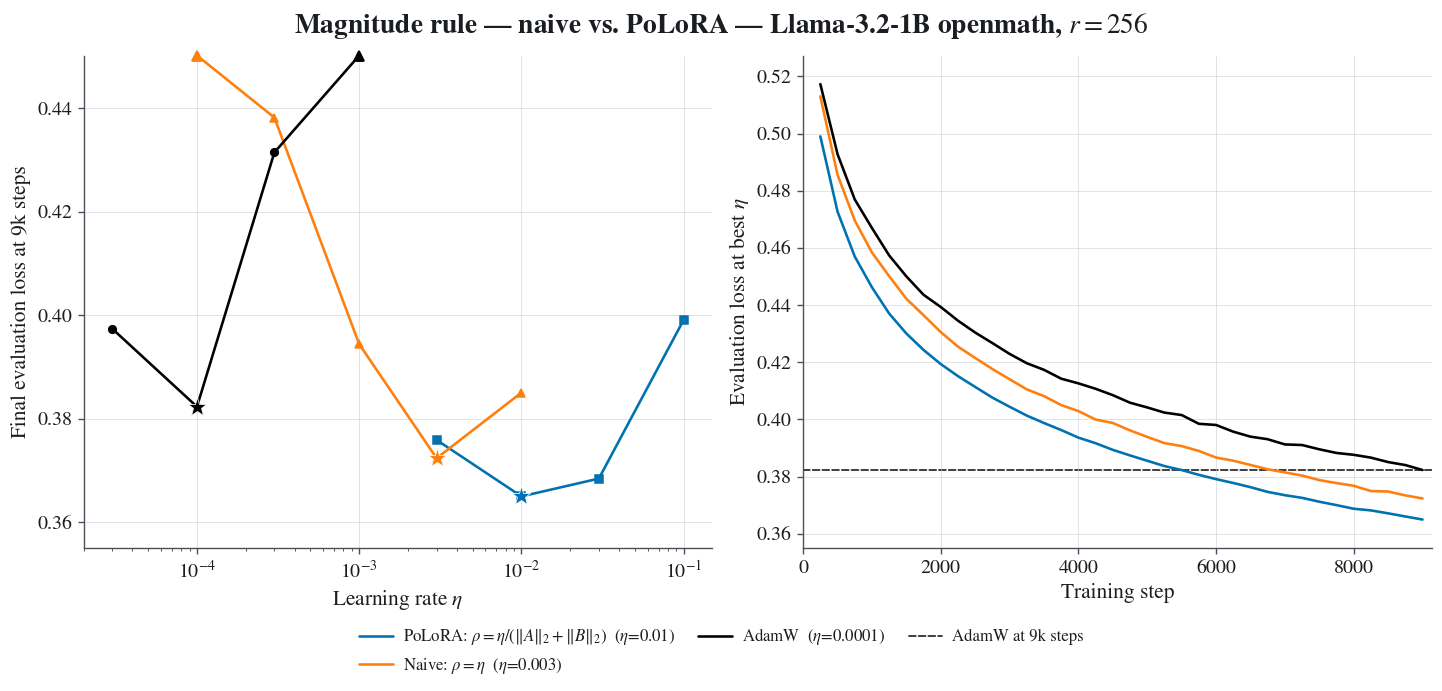

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                     best eta    final   speedup   lr-avg  n_lr
  PoLoRA: $\rho=\eta/(\|A\|_2+\|B\|_2)$       0.01   0.3650     1.64x    1.40x  4
  Naive: $\rho=\eta$                         0.003   0.3724     1.32x    1.09x  5
  AdamW                                     0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,PoLoRA: $\rho=\eta/(\|A\|_2+\|B\|_2)$,0.0100,0.364971,NaN,NaN,4
1,Naive: $\rho=\eta$,0.0030,0.372352,0.007380,4.341388,1
2,AdamW,0.0001,0.382301,0.017329,10.193808,1


In [118]:
P.magnitude_rule_panel(256)


## Question 3 — What should fill the r×r metric slot, and does the answer transfer?

### Figure 19. Llama-3.2-1B · OpenMath · r=16

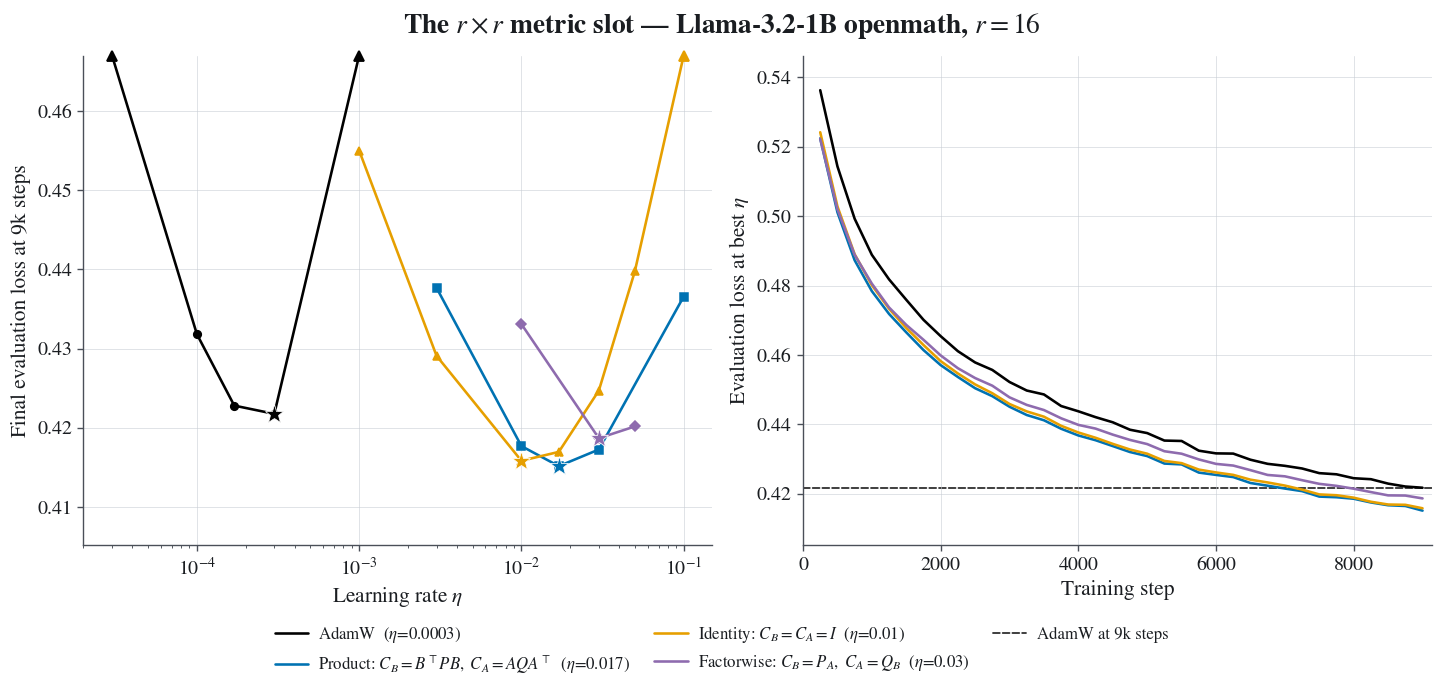

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.017   0.4152     1.30x    1.23x  5
  Identity: $C_B=C_A=I$                            0.01   0.4158     1.26x    1.15x  7
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.03   0.4187     1.14x    1.06x  3
  AdamW                                          0.0003   0.4218     1.00x    1.00x  5
7 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,0.006601,3.883152,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0170,0.415162,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.0100,0.415841,0.000679,0.399347,2
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.0300,0.418685,0.003523,2.072627,1


In [120]:
P.precond_panel(16)


### Figure 20. Llama-3.2-1B · OpenMath · r=64

no data yet (omitted): Factorwise: $C_B=P_A,\ C_A=Q_B$


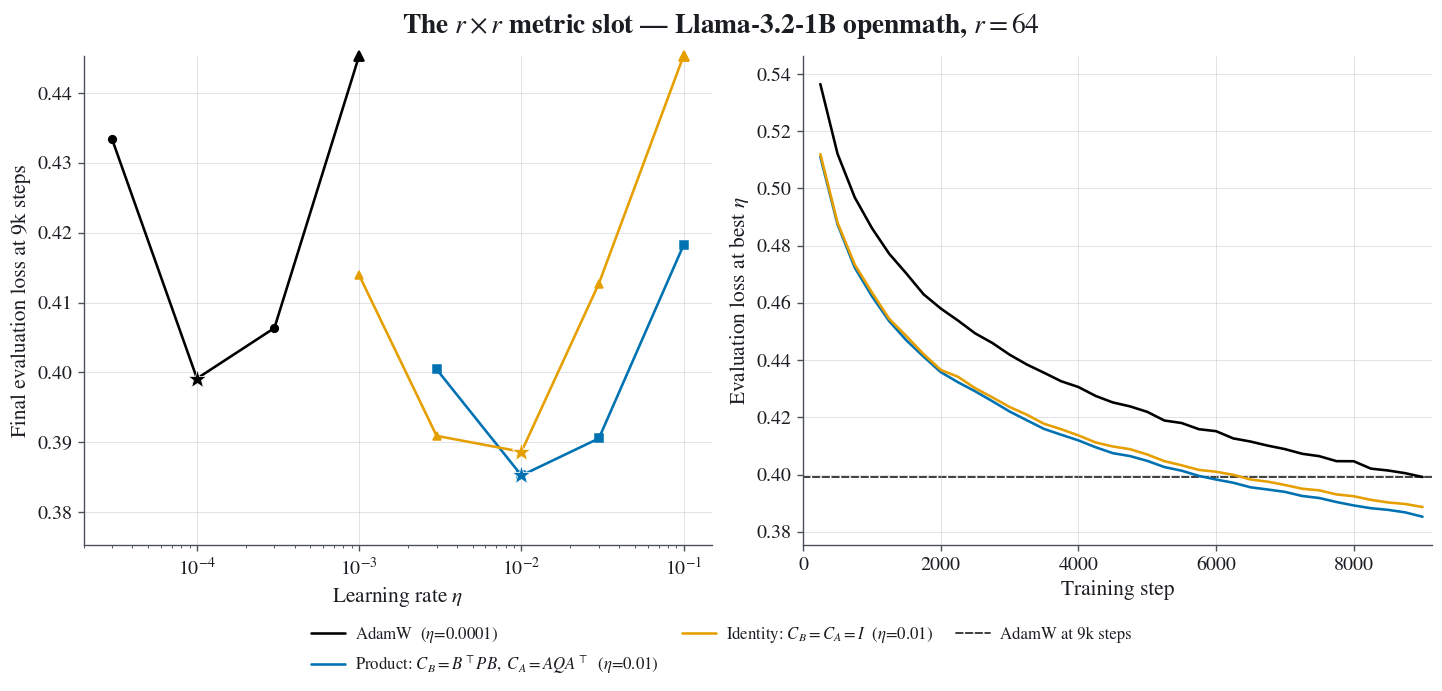

speedup vs AdamW (target 0.3991, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$       0.01   0.3853     1.54x    1.25x  4
  Identity: $C_B=C_A=I$                            0.01   0.3886     1.41x    1.20x  5
  AdamW                                          0.0001   0.3991     1.00x    1.00x  4
5 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.399128,0.013874,8.160944,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0100,0.385254,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.0100,0.388649,0.003395,1.996805,1


In [121]:
P.precond_panel(64)


### Figure 21. Llama-3.2-1B · OpenMath · r=256

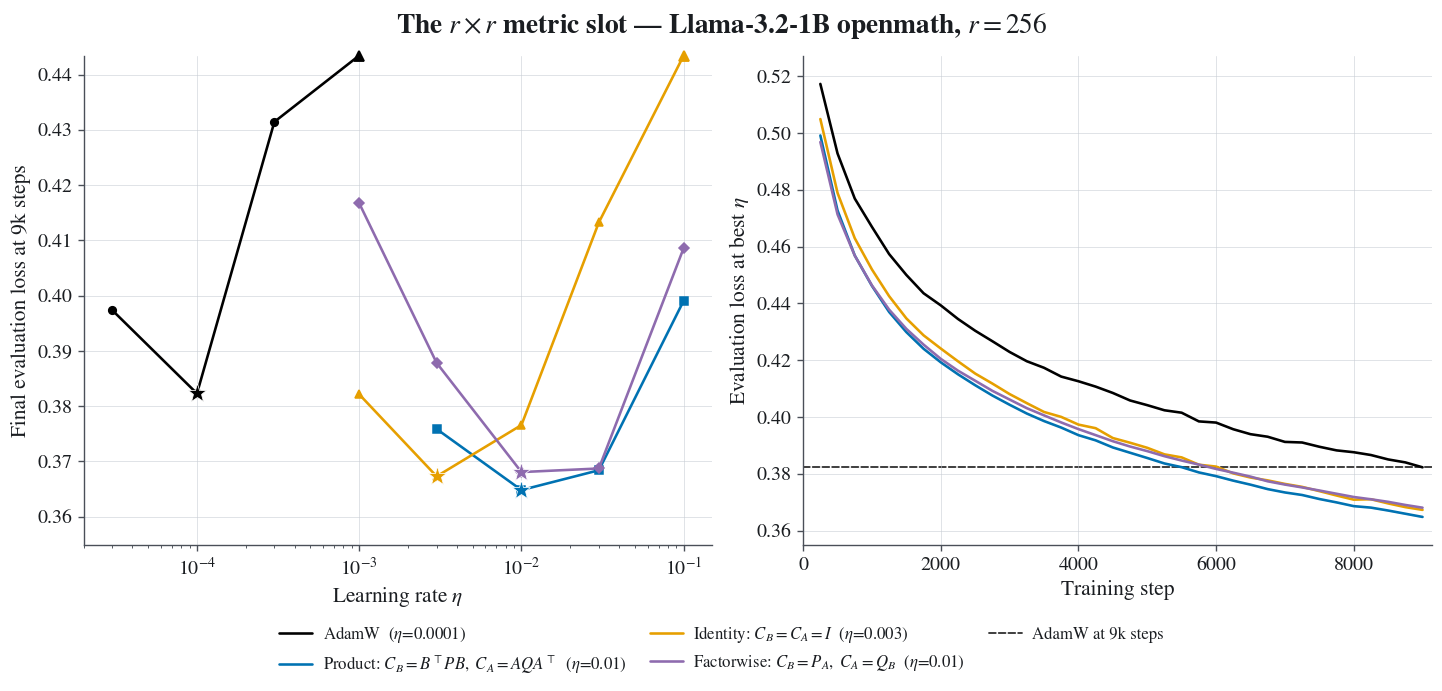

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$       0.01   0.3648     1.63x    1.40x  4
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.01   0.3681     1.52x    1.29x  5
  Identity: $C_B=C_A=I$                           0.003   0.3673     1.49x    1.20x  5
  AdamW                                          0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.382301,0.017470,10.276285,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0100,0.364831,NaN,NaN,5
2,Identity: $C_B=C_A=I$,0.0030,0.367310,0.002479,1.458386,1
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.0100,0.368085,0.003254,1.914135,4


In [119]:
P.precond_panel(256)


### Figure 22. Qwen2.5-1.5B · OpenMath · r=16

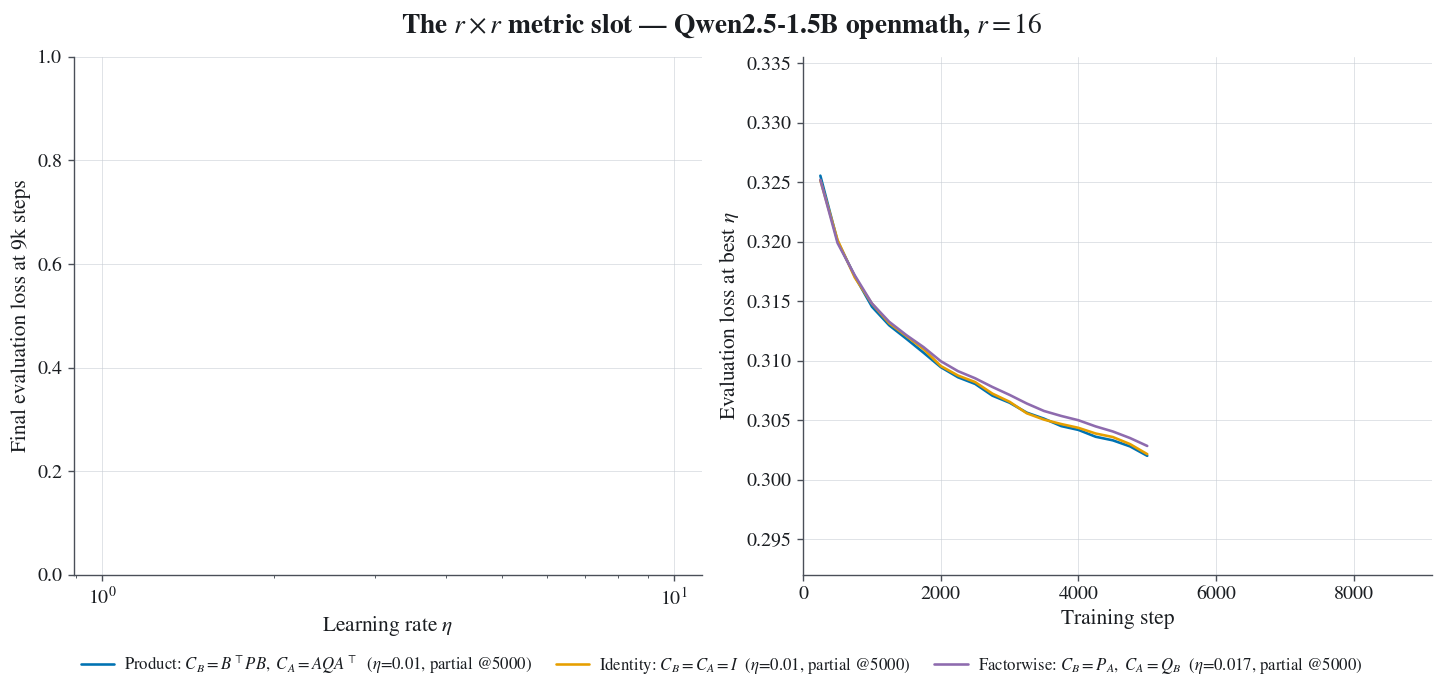

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n


In [123]:
P.precond_panel(
    16,
    model="Qwen/Qwen2.5-1.5B",
    model_label="Qwen2.5-1.5B",
    matched_revision=True,
)


### Figure 23. Qwen2.5-1.5B · OpenMath · r=256

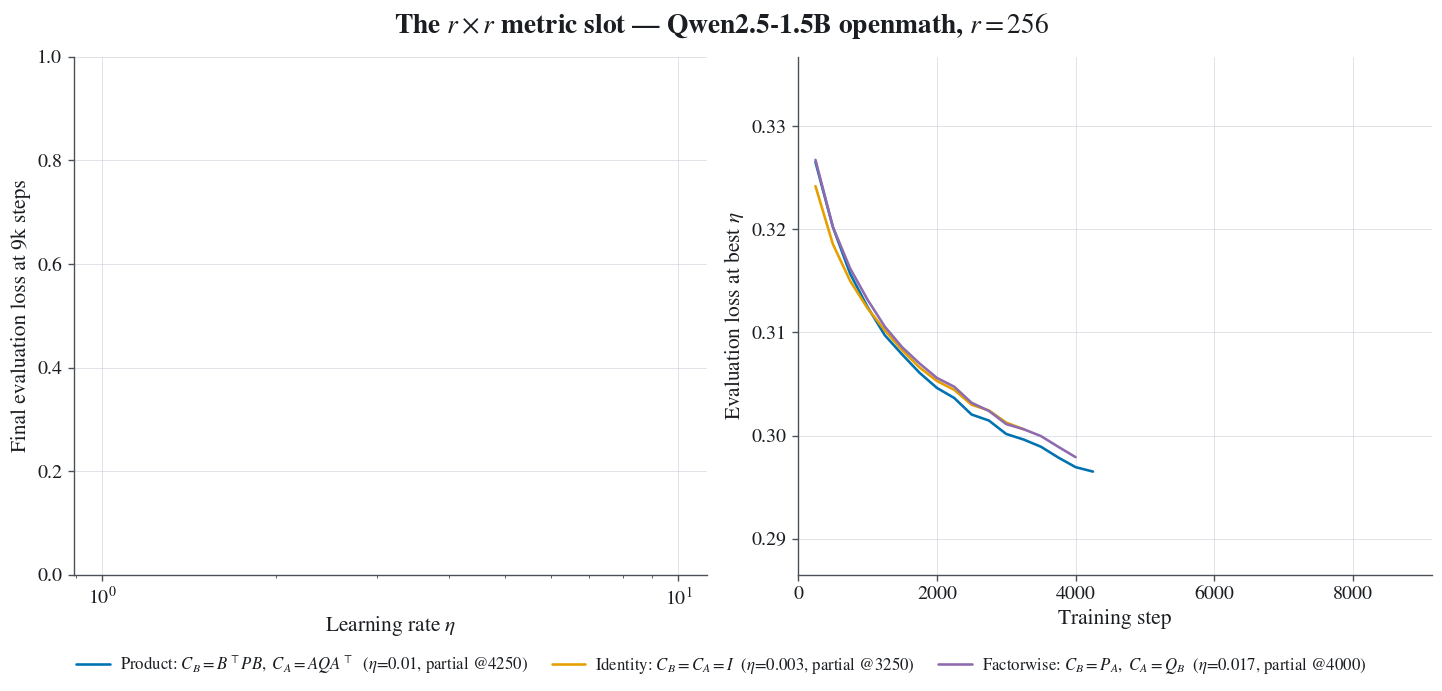

no speedup table: this panel declares no speed target.
10 run(s) excluded by 'precond_matched' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n


In [122]:
P.precond_panel(
    256,
    model="Qwen/Qwen2.5-1.5B",
    model_label="Qwen2.5-1.5B",
    matched_revision=True,
)


### Figure 24. Llama-3.2-1B · OPC · r=256

no data yet (omitted): Factorwise: $C_B=P_A,\ C_A=Q_B$


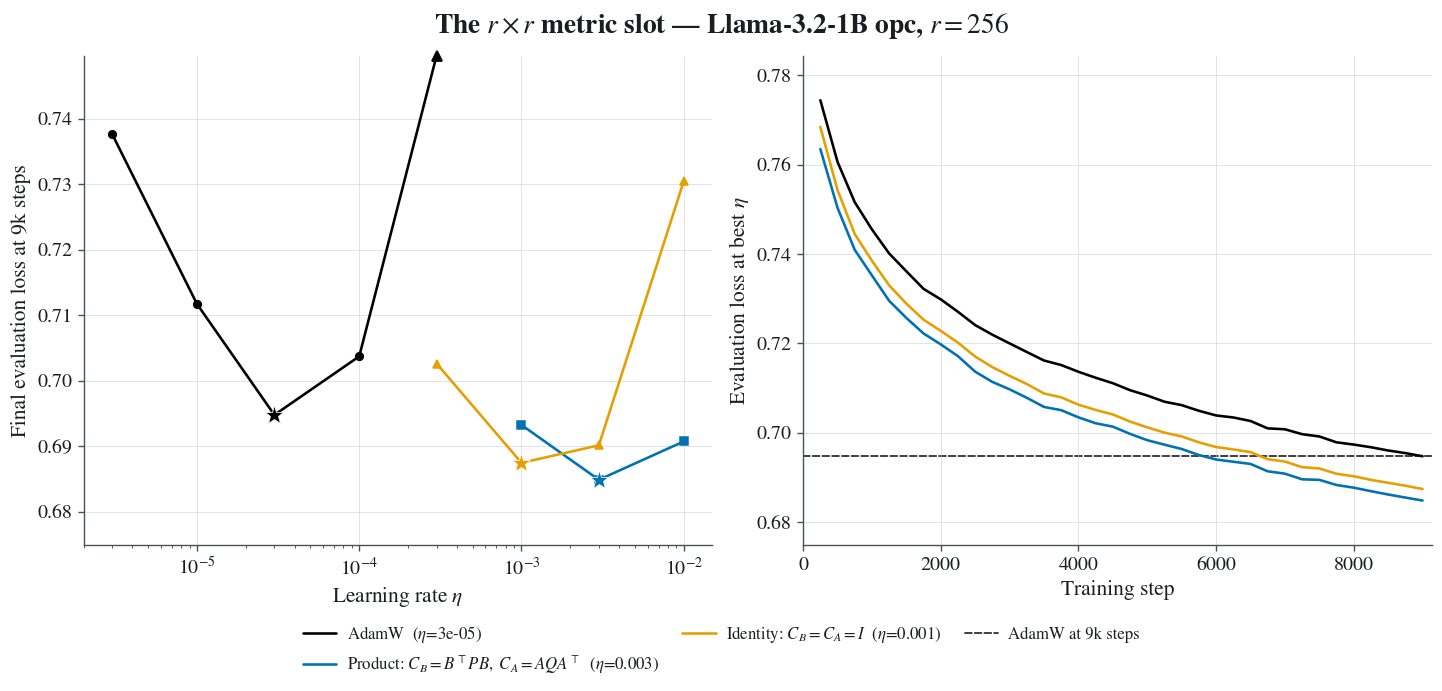

speedup vs AdamW (target 0.6948, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.003   0.6848     1.55x    1.24x  3
  Identity: $C_B=C_A=I$                           0.001   0.6874     1.35x    1.16x  4
  AdamW                                           3e-05   0.6948     1.00x    1.00x  5
4 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.694754,0.009905,5.826258,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.00300,0.684849,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.00100,0.687435,0.002586,1.520991,1


In [124]:
P.precond_panel(256, data_key="opc")


### Figure 25. Qwen2.5-1.5B · OPC · r=256

no data yet (omitted): Factorwise: $C_B=P_A,\ C_A=Q_B$


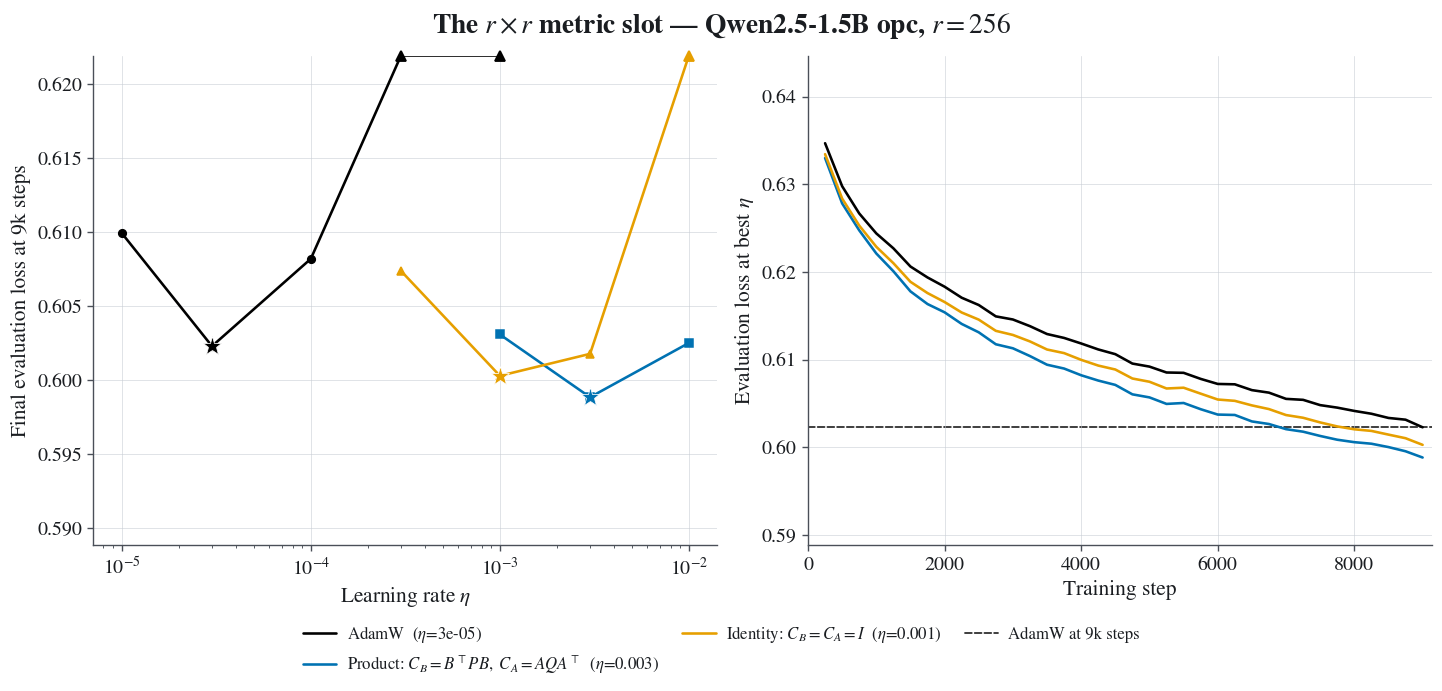

speedup vs AdamW (target 0.6023, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.003   0.5988     1.30x    1.08x  3
  Identity: $C_B=C_A=I$                           0.001   0.6003     1.15x    1.05x  4
  AdamW                                           3e-05   0.6023     1.00x    1.00x  5
4 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.602292,0.003447,2.027497,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.00300,0.598845,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.00100,0.600290,0.001445,0.849825,1


In [125]:
P.precond_panel(256, model="Qwen/Qwen2.5-1.5B", data_key="opc", model_label="Qwen2.5-1.5B")


## Question 4 — How sensitive are the estimators to their memory horizon?

### Figure 26. Metric-slot β₂ sensitivity at r=16

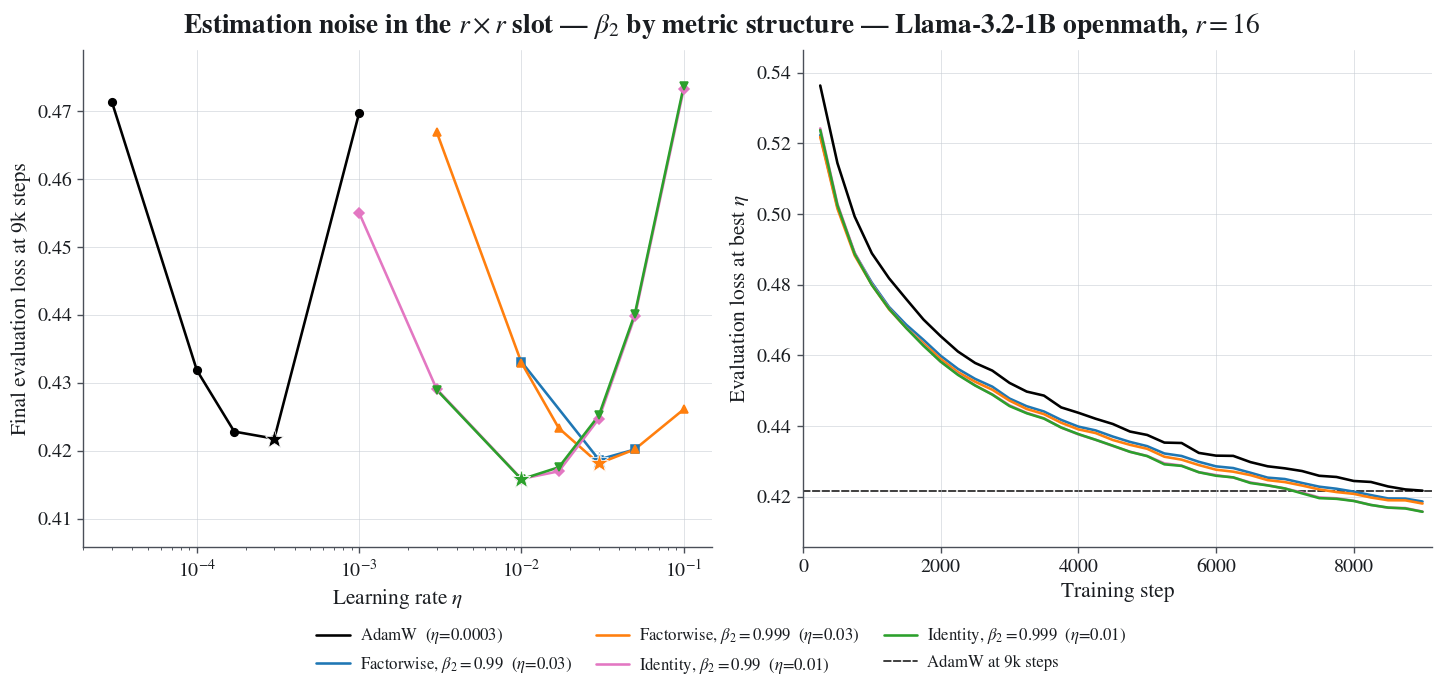

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                           best eta    final   speedup   lr-avg  n_lr
  Identity, $\beta_2=0.999$         0.01   0.4158     1.27x    1.15x  6
  Identity, $\beta_2=0.99$          0.01   0.4158     1.26x    1.15x  7
  Factorwise, $\beta_2=0.999$       0.03   0.4181     1.18x    1.07x  6
  Factorwise, $\beta_2=0.99$        0.03   0.4187     1.14x    1.06x  3
  AdamW                           0.0003   0.4218     1.00x    1.00x  5
7 run(s) excluded by 'precond_beta2' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,0.005922,3.483805,1
1,"Factorwise, $\beta_2=0.99$",0.0300,0.418685,0.002845,1.673279,1
2,"Factorwise, $\beta_2=0.999$",0.0300,0.418115,0.002275,1.338061,1
3,"Identity, $\beta_2=0.99$",0.0100,0.415841,NaN,NaN,2
4,"Identity, $\beta_2=0.999$",0.0100,0.415791,-0.000050,-0.029362,1


In [126]:
P.precond_beta2_panel(16)   # beta2 x precond at r=16, 9000 steps


### Figure 27. PoLoRA curvature β₂ sweep

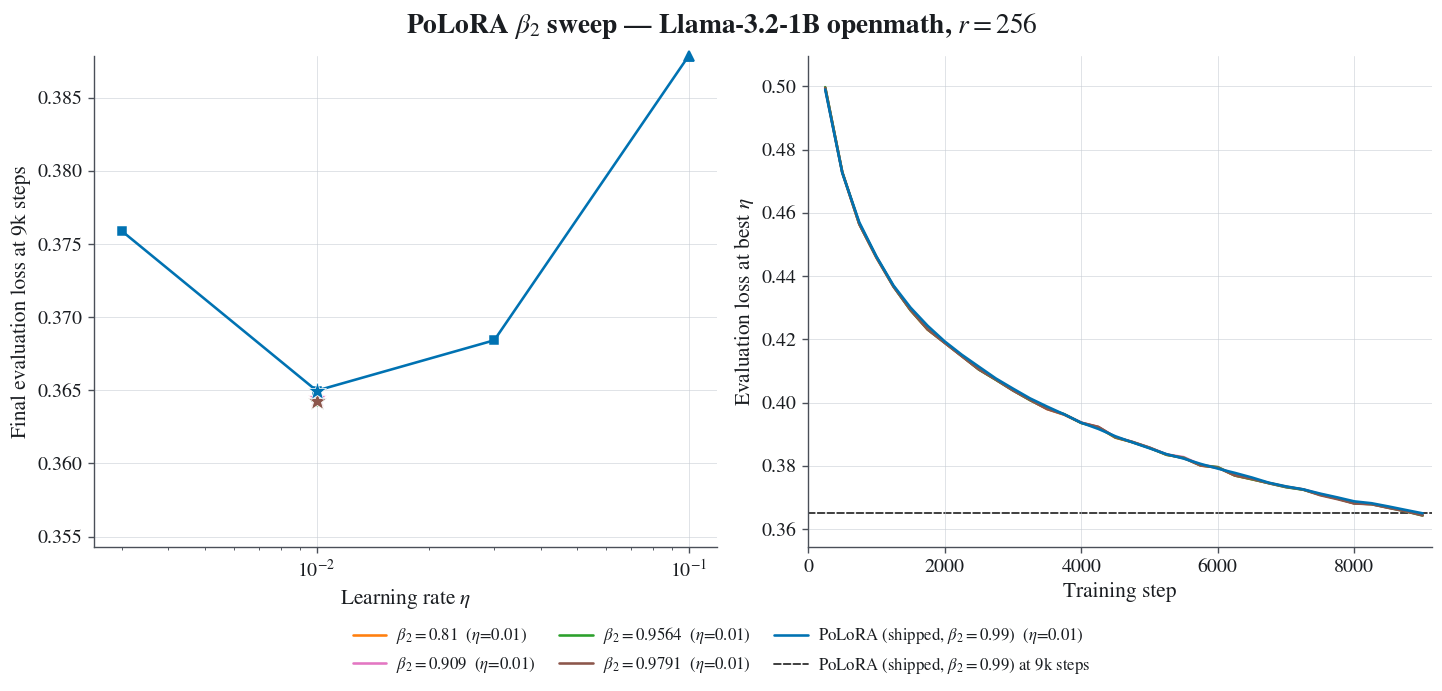

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,$\beta_2=0.81$,0.01,0.364447,-0.000524,-0.308196,1
1,$\beta_2=0.909$,0.01,0.364445,-0.000526,-0.309413,1
2,$\beta_2=0.9564$,0.01,0.364279,-0.000692,-0.406913,1
3,$\beta_2=0.9791$,0.01,0.364299,-0.000672,-0.395394,1
4,"PoLoRA (shipped, $\beta_2=0.99$)",0.01,0.364971,NaN,NaN,4


In [127]:
P.beta2_panel(256)


### Figure 28. AdamW β₂ control

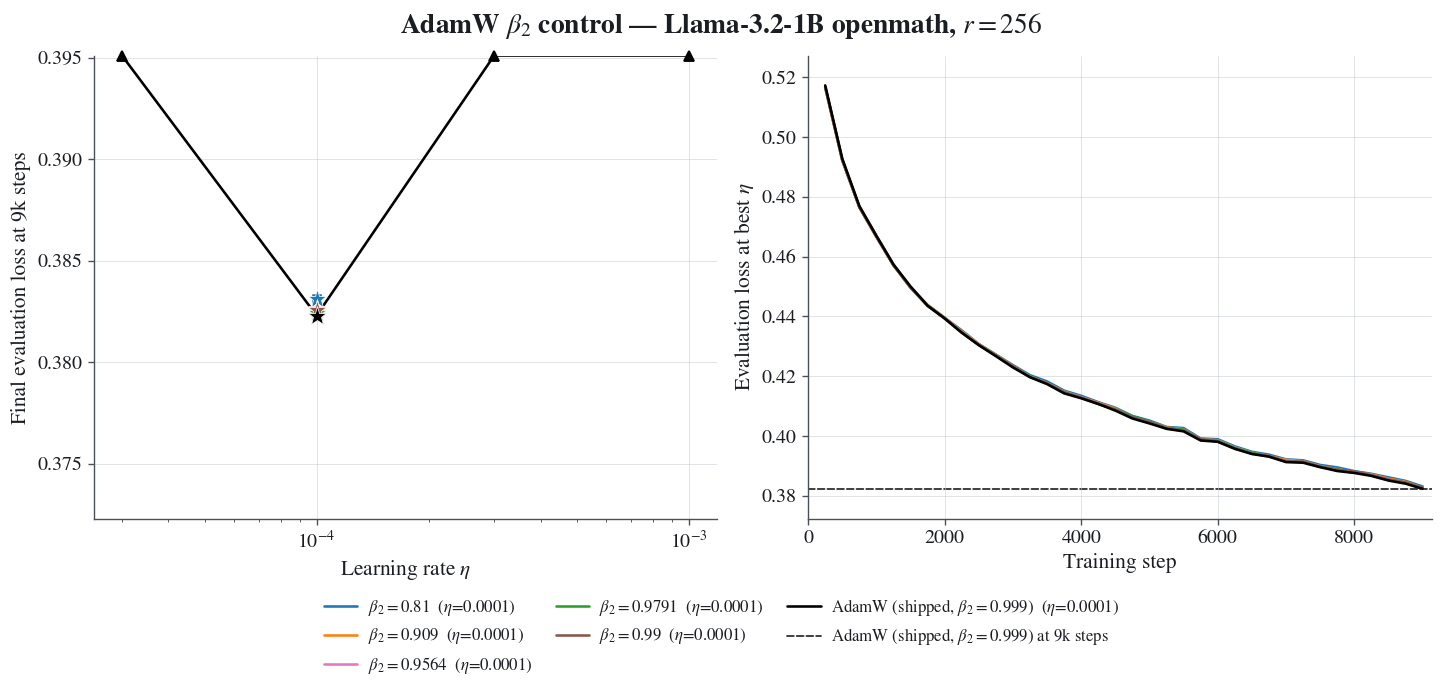

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,$\beta_2=0.81$,0.0001,0.383098,0.000798,0.469290,1
1,$\beta_2=0.909$,0.0001,0.382621,0.000320,0.188174,1
2,$\beta_2=0.9564$,0.0001,0.382463,0.000163,0.095758,1
3,$\beta_2=0.9791$,0.0001,0.382440,0.000140,0.082245,1
4,$\beta_2=0.99$,0.0001,0.382597,0.000296,0.174124,1
5,"AdamW (shipped, $\beta_2=0.999$)",0.0001,0.382301,NaN,NaN,1


In [128]:
P.adamw_beta2_panel(256)


## Question 5 — Do factor-geometry and magnitude diagnostics support the mechanism?

### Figure 29. Gauge diagnostics at r=256

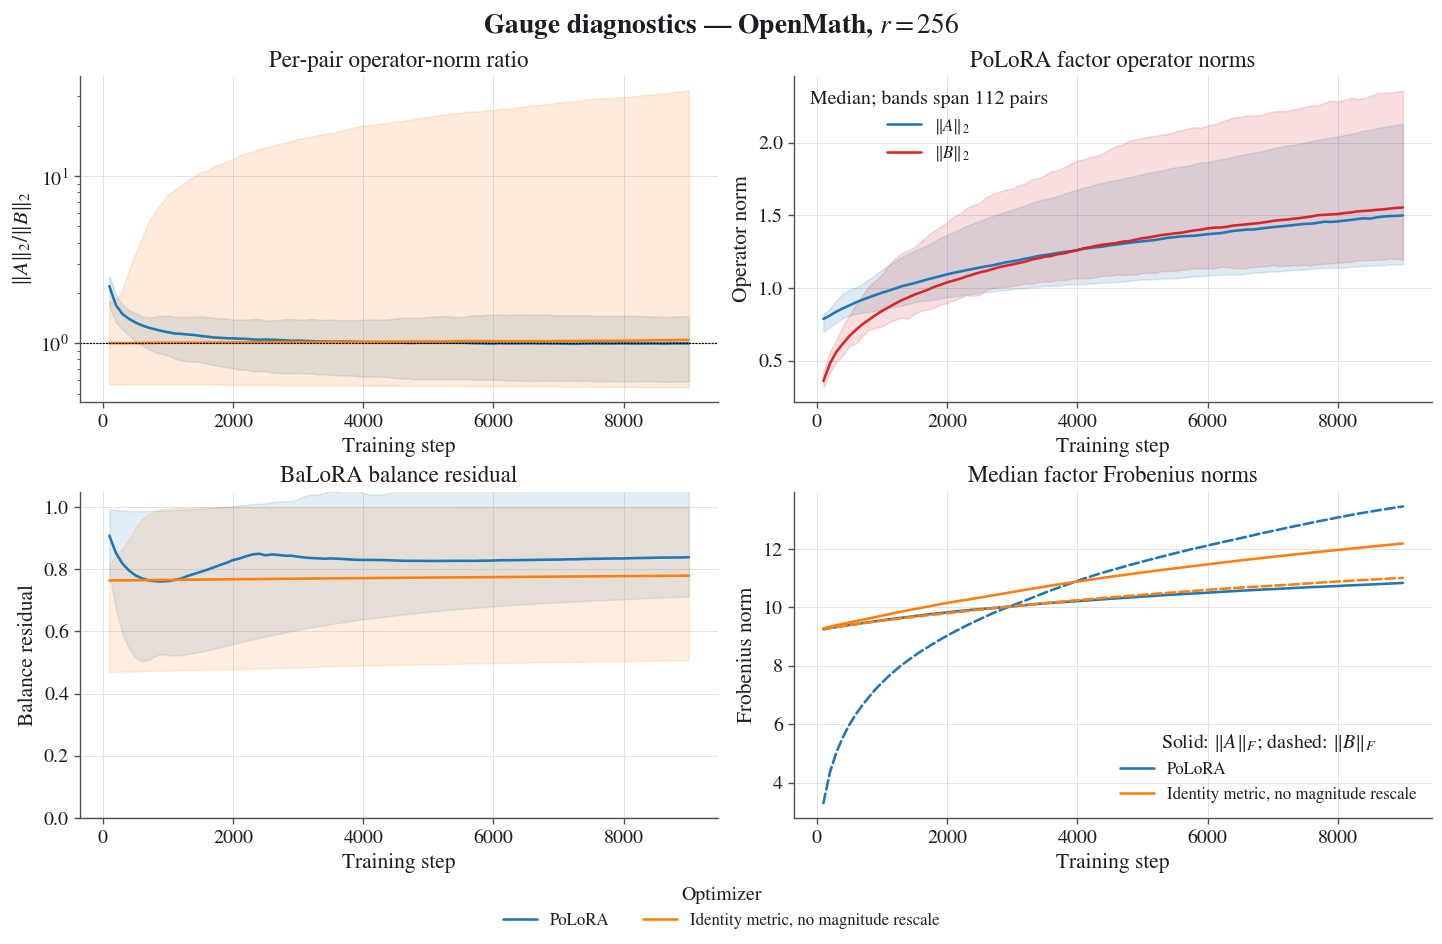

In [129]:
# Exploratory gauge diagnostics: read per-step, per-pair optimizer diagnostics.
import json, glob
import numpy as np
import matplotlib.pyplot as plt

def gtraj(group):
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        rows=[json.loads(l) for l in open(f) if '"balance_resid_median"' in l]
        rows=[r for r in rows if r.get('event')=='optim_step']
        if rows:
            g=lambda k: np.array([r.get(k,np.nan) for r in rows], float)
            return {k:g(k) for k in ('step','sigma_max_A_median','sigma_max_A_min','sigma_max_A_max',
                'sigma_max_B_median','sigma_max_B_min','sigma_max_B_max','sigma_ratio_median',
                'sigma_ratio_min','sigma_ratio_max','balance_resid_median','balance_resid_min',
                'balance_resid_max','norm_A_median','norm_B_median')}
    return None

ARMS={'PoLoRA':'gauge_kldiag_r256_bw','Identity metric, no magnitude rescale':'gauge_loramuon_r256_bw'}
D={k:gtraj(v) for k,v in ARMS.items()}
fig,ax=plt.subplots(2,2,figsize=(13,8.5), constrained_layout=True)

for i,(lab,d) in enumerate(D.items()):
    if d is None: continue
    ax[0,0].fill_between(d['step'],d['sigma_ratio_min'],d['sigma_ratio_max'],color=f'C{i}',alpha=.15)
    ax[0,0].plot(d['step'],d['sigma_ratio_median'],f'C{i}',label=lab)
ax[0,0].axhline(1,color='k',ls=':',lw=.8); ax[0,0].set_yscale('log')
ax[0,0].set_title('Per-pair operator-norm ratio')
ax[0,0].set_xlabel('Training step'); ax[0,0].set_ylabel(r'$\|A\|_2/\|B\|_2$')
arm_handles, arm_labels = ax[0,0].get_legend_handles_labels()

d=D['PoLoRA']
if d is not None:
    ax[0,1].fill_between(d['step'],d['sigma_max_A_min'],d['sigma_max_A_max'],color='C0',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_A_median'],'C0',label=r'$\|A\|_2$')
    ax[0,1].fill_between(d['step'],d['sigma_max_B_min'],d['sigma_max_B_max'],color='C3',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_B_median'],'C3',label=r'$\|B\|_2$')
ax[0,1].set_title('PoLoRA factor operator norms')
ax[0,1].set_xlabel('Training step'); ax[0,1].set_ylabel('Operator norm')
ax[0,1].legend(title='Median; bands span 112 pairs', frameon=False)

for i,(lab,d) in enumerate(D.items()):
    if d is None: continue
    ax[1,0].fill_between(d['step'],d['balance_resid_min'],d['balance_resid_max'],color=f'C{i}',alpha=.13)
    ax[1,0].plot(d['step'],d['balance_resid_median'],f'C{i}',label=lab)
ax[1,0].axhline(0,color='k',ls=':',lw=.8); ax[1,0].set_ylim(0,1.05)
ax[1,0].set_title('BaLoRA balance residual')
ax[1,0].set_xlabel('Training step'); ax[1,0].set_ylabel('Balance residual')

for i,(lab,d) in enumerate(D.items()):
    if d is None: continue
    ax[1,1].plot(d['step'],d['norm_A_median'],f'C{i}',label=lab)
    ax[1,1].plot(d['step'],d['norm_B_median'],f'C{i}',ls='--',label='_nolegend_')
ax[1,1].set_title('Median factor Frobenius norms')
ax[1,1].set_xlabel('Training step'); ax[1,1].set_ylabel('Frobenius norm')
ax[1,1].legend(title=r'Solid: $\|A\|_F$; dashed: $\|B\|_F$', frameon=False)

fig.suptitle(r'Gauge diagnostics — OpenMath, $r=256$')
fig.legend(
    arm_handles, arm_labels, title='Optimizer',
    loc='outside lower center', ncol=2, frameon=False,
)
plt.show()


### Figure 30. Does operator-norm self-balancing weaken at r=16?

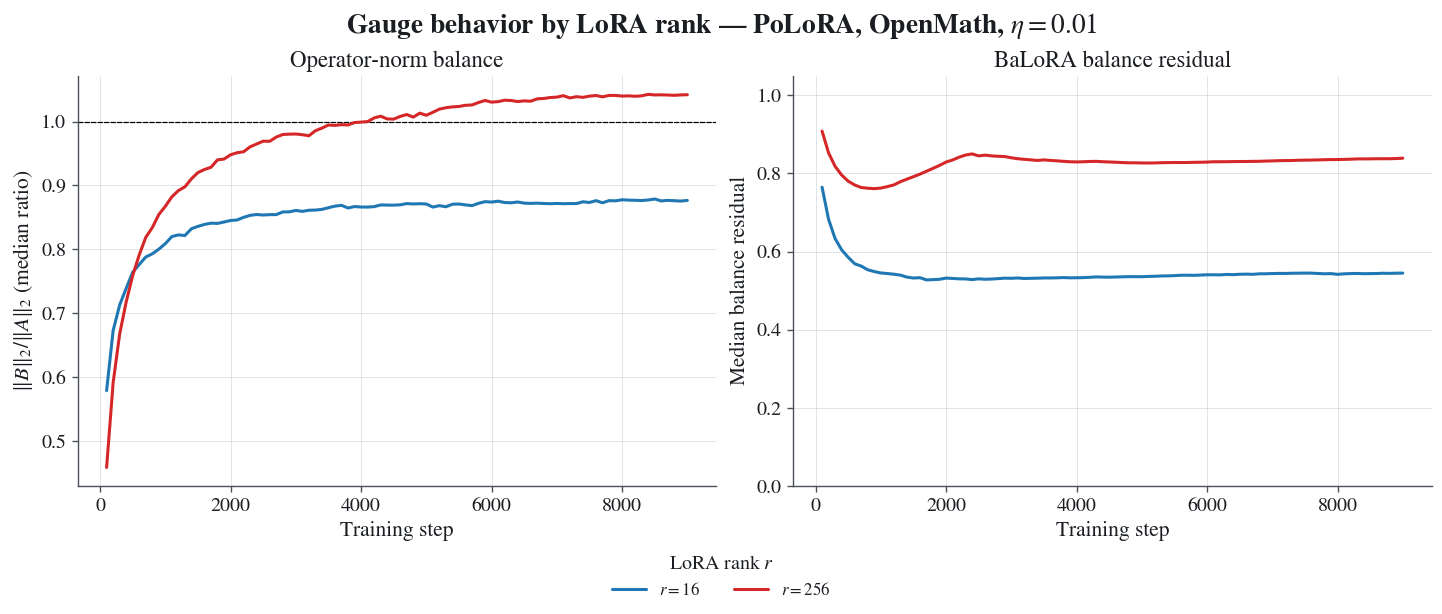

In [130]:
# Rank comparison for PoLoRA gauge diagnostics at matched learning rate.
import json, glob
import numpy as np
import matplotlib.pyplot as plt

def otraj(group, lr_want=0.01):
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        lr=None; S=[]; rat=[]; br=[]
        for l in open(f):
            if '"event": "config"' in l:
                try: lr=float(json.loads(l).get('lr'))
                except: pass
            elif 'sigma_max_A_median' in l and '"event": "optim_step"' in l:
                e=json.loads(l); S.append(e['step'])
                rat.append(e['sigma_max_B_median']/e['sigma_max_A_median']); br.append(e['balance_resid_median'])
        if lr is not None and abs(lr-lr_want)<1e-9 and S:
            return np.array(S), np.array(rat), np.array(br)
    return None

ARMS=[(r'$r=16$','e1_kldiag_llama32_openmath_r16r32_bw','C0'),
      (r'$r=256$','e1_kldiag_llama32_openmath_r256_bw','C3')]
fig,ax=plt.subplots(1,2,figsize=(13,5.5), constrained_layout=True)
ax[0].axhline(1,color='k',ls='--',lw=.8)
for lab,grp,c in ARMS:
    d=otraj(grp)
    if d is None: continue
    ax[0].plot(d[0],d[1],c,lw=2,label=lab); ax[1].plot(d[0],d[2],c,lw=2,label=lab)
rank_handles, rank_labels = ax[0].get_legend_handles_labels()
ax[0].set_xlabel('Training step'); ax[0].set_ylabel(r'$\|B\|_2/\|A\|_2$ (median ratio)')
ax[0].set_title('Operator-norm balance')
ax[1].set_ylim(0,1.05); ax[1].set_xlabel('Training step'); ax[1].set_ylabel('Median balance residual')
ax[1].set_title('BaLoRA balance residual')
fig.suptitle(r'Gauge behavior by LoRA rank — PoLoRA, OpenMath, $\eta=0.01$')
fig.legend(
    rank_handles, rank_labels, title=r'LoRA rank $r$',
    loc='outside lower center', ncol=2, frameon=False,
)
plt.show()


### Figure 31. Does the solved magnitude rule track its bound?

In [131]:
# Live tracking (compute): eval trajectories straight from the groups' logs.
# Direct log read (same pattern as the gauge cells) — live-safe mid-run; the
# loader/logs-cache is bypassed on purpose so re-running refreshes.
import json, glob

SOLVED_GROUPS = ['solvedrho_kldiag_llama32_openmath_r256_bw',
                 'solvedrho_kldiag_llama32_openmath_r256_lrext_bw']  # lr ext {3e-4, 1e-3}
BOUND_GROUP = 'e1_kldiag_llama32_openmath_r256_bw'

def _eval_trajs(group):
    """{lr: (steps, losses)} from each log_*.out's config + eval events."""
    out = {}
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        lr = None; S = []; L = []
        for line in open(f):
            if '"event": "config"' in line:
                try: lr = float(json.loads(line).get('lr'))
                except Exception: pass
            elif '"event": "eval"' in line:
                try:
                    e = json.loads(line)
                    if e.get('eval_loss') is not None:
                        S.append(e['step']); L.append(e['eval_loss'])
                except Exception: pass  # mid-write partial line
        if lr is not None and S:
            out[lr] = (S, L)
    return dict(sorted(out.items()))

solved_trajs = {}
for g in SOLVED_GROUPS:
    solved_trajs.update(_eval_trajs(g))
solved_trajs = dict(sorted(solved_trajs.items()))
bound_trajs = _eval_trajs(BOUND_GROUP)
for lab, d in (('solved', solved_trajs), ('bound', bound_trajs)):
    print(lab, {lr: (S[-1], round(L[-1], 4)) for lr, (S, L) in d.items()})


solved {0.0003: (9000, 0.4128), 0.001: (9000, 0.3783), 0.003: (9000, 0.3692), 0.01: (9000, 0.3941), 0.03: (9000, 0.4523)}
bound {0.003: (9000, 0.3759), 0.01: (9000, 0.3643), 0.03: (9000, 0.3684)}


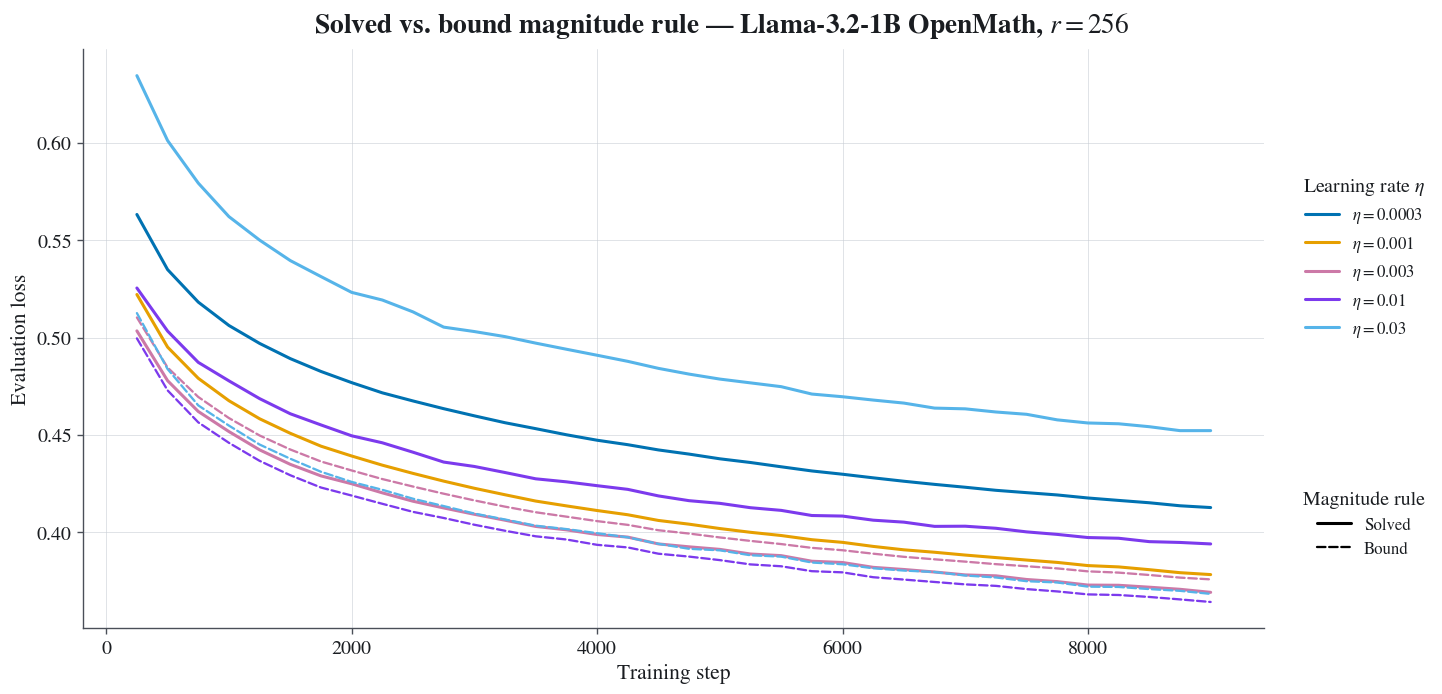

solved: best learning rate=0.003 final=0.3692
bound: best learning rate=0.01 final=0.3643


In [132]:
# Live tracking: solved versus bound magnitude rule. Color encodes learning
# rate; linestyle encodes the rule, with separate keys for the two factors.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from lora_playground.plotting.colors import SERIES_PALETTE, distinct_palette

lrs = sorted(set(solved_trajs) | set(bound_trajs))
COLOR = dict(zip(lrs, distinct_palette(len(lrs), reserved=[], source=list(SERIES_PALETTE))))

fig, ax = plt.subplots(figsize=(13,6.2), constrained_layout=True)
rules = (('Solved', solved_trajs, '-', 2.0), ('Bound', bound_trajs, '--', 1.5))
for _arm, trajs, ls, lw in rules:
    for lr, (S, L) in sorted(trajs.items()):
        ax.plot(S, L, ls=ls, lw=lw, color=COLOR[lr])

eta_handles = [
    Line2D([], [], color=COLOR[lr], lw=2, label=rf'$\eta={lr:g}$')
    for lr in lrs
]
rule_handles = [
    Line2D([], [], color='black', ls=ls, lw=lw, label=arm)
    for arm, _trajs, ls, lw in rules
]
eta_legend = ax.legend(
    handles=eta_handles, title=r'Learning rate $\eta$',
    loc='center left', bbox_to_anchor=(1.02,0.64), frameon=False,
)
ax.add_artist(eta_legend)
ax.legend(
    handles=rule_handles, title='Magnitude rule',
    loc='center left', bbox_to_anchor=(1.02,0.18), frameon=False,
)
ax.set_xlabel('Training step'); ax.set_ylabel('Evaluation loss')
fig.suptitle(r'Solved vs. bound magnitude rule — Llama-3.2-1B OpenMath, $r=256$')
plt.show()

# Best-learning-rate readout for the two rules.
for arm, trajs in (('solved', solved_trajs), ('bound', bound_trajs)):
    best = min(trajs.items(), key=lambda kv: kv[1][1][-1])
    print(f'{arm}: best learning rate={best[0]:g} final={best[1][1][-1]:.4f}')
